# **Imported Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyswarms as ps

from pyswarms.single import GlobalBestPSO
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import recall_score, precision_score, accuracy_score, confusion_matrix, classification_report, f1_score, balanced_accuracy_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

# **Exploraity Data Analysis**  

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [5]:
df.shape

(100000, 9)

In [6]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

In [7]:
target = 'diabetes'
df[target].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

In [8]:
#b4oof meen column numeric w meen categorigal hnb2a n3mlha encoding

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numeric columns: {numeric_cols}')
print(f'Categorical columns: {categorical_cols}')

Numeric columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
Categorical columns: ['gender', 'smoking_history']


C:\Users\nourw\AppData\Local\Temp\ipykernel_51800\1674946984.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [9]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [10]:
df.nunique()

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

In [11]:
df[target].value_counts(normalize=True) * 100   #de 3l4an n4oof percentage kol class

diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64

In [12]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [13]:
# b column names to lowercase and removes extra spaces 3l4an Standardizing column names prevents future errors

df.columns = df.columns.str.lower().str.strip()
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'hba1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

In [14]:
#It shows all categories inside, Categorical columns often contain problems like, Male, male, MALE while they are the same
for col in ["gender", "smoking_history"]:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: gender
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Column: smoking_history
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


In [15]:
for col in ["gender", "smoking_history"]:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(normalize=True) * 100)


Column: gender
gender
Female    58.552
Male      41.430
Other      0.018
Name: proportion, dtype: float64

Column: smoking_history
smoking_history
No Info        35.816
never          35.095
former          9.352
current         9.286
not current     6.447
ever            4.004
Name: proportion, dtype: float64


In [16]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_count / len(df) * 100)

Duplicate rows: 3854
Duplicate percentage: 3.8539999999999996


In [17]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
10,Female,53.0,0,0,never,27.32,6.1,85,0
14,Female,76.0,0,0,No Info,27.32,5.0,160,0
18,Female,42.0,0,0,No Info,27.32,5.7,80,0
41,Male,5.0,0,0,No Info,27.32,6.6,130,0
44,Female,67.0,0,0,No Info,27.32,3.5,160,0
51,Female,26.0,0,0,No Info,27.32,4.0,200,0
56,Male,30.0,0,0,No Info,27.32,6.6,140,0
62,Female,30.0,0,0,current,27.32,6.5,158,0
95,Male,19.0,0,0,never,27.32,6.1,80,0


In [18]:
numeric_cols = ["age", "bmi", "hba1c_level", "blood_glucose_level"]

range_table = pd.DataFrame({
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max(),
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median()
})

range_table

,min,max,mean,median
age,0.08,80.00,41.885856,43.00
bmi,10.01,95.69,27.320767,27.32
hba1c_level,3.50,9.00,5.527507,5.80
blood_glucose_level,80.00,300.00,138.058060,140.00


In [19]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(20)  #Check whether duplicates affect the target

,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes
47708,Female,2.0,0,0,No Info,27.32,5.0,158,0
59468,Female,2.0,0,0,No Info,27.32,5.0,158,0
62073,Female,2.0,0,0,No Info,27.32,6.0,85,0
67439,Female,2.0,0,0,No Info,27.32,6.0,85,0
23617,Female,2.0,0,0,No Info,27.32,6.0,145,0
67234,Female,2.0,0,0,No Info,27.32,6.0,145,0
90685,Female,2.0,0,0,No Info,27.32,6.2,145,0
97294,Female,2.0,0,0,No Info,27.32,6.2,145,0
46785,Female,2.0,0,0,No Info,27.32,6.5,155,0
89701,Female,2.0,0,0,No Info,27.32,6.5,155,0


In [20]:
#Check duplicate target distribution
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows["diabetes"].value_counts(normalize=True) * 100

diabetes
0    99.495605
1     0.504395
Name: proportion, dtype: float64

In [21]:
#Inspect the rare Other gender rows
df[df["gender"] == "Other"]

,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes
12669,Other,10.0,0,0,not current,14.09,5.0,140,0
14838,Other,19.0,0,0,No Info,27.32,5.7,158,0
16702,Other,39.0,0,0,not current,31.24,6.2,85,0
18691,Other,10.0,0,0,not current,16.59,6.1,160,0
23266,Other,23.0,0,0,No Info,24.23,6.1,140,0
31985,Other,53.0,0,0,No Info,27.32,6.6,160,0
33805,Other,45.0,0,0,never,27.32,4.0,159,0
34929,Other,47.0,0,0,never,36.76,6.6,90,0
35006,Other,47.0,0,0,never,36.76,3.5,200,0
40337,Other,18.0,0,0,not current,30.19,6.1,90,0


In [22]:
#Check diabetes rate by gender
df.groupby("gender")["diabetes"].agg(["count", "mean"])

,count,mean
gender,,
Female,58552,0.076189
Male,41430,0.097490
Other,18,0.000000


In [23]:
#Check diabetes rate by smoking history
df.groupby("smoking_history")["diabetes"].agg(["count", "mean"]).sort_values(by="mean", ascending=False)

,count,mean
smoking_history,,
former,9352,0.170017
ever,4004,0.117882
not current,6447,0.107027
current,9286,0.102089
never,35095,0.095341
No Info,35816,0.040596


In [24]:
#Compare numerical features by diabetes status
numeric_cols = ["age", "bmi", "hba1c_level", "blood_glucose_level"]

df.groupby("diabetes")[numeric_cols].mean()

,age,bmi,hba1c_level,blood_glucose_level
diabetes,,,,
0,40.115187,26.887163,5.396761,132.852470
1,60.946588,31.988382,6.934953,194.094706


In [25]:
#Better comparison using median too
df.groupby("diabetes")[numeric_cols].agg(["mean", "median"])

age               bmi        hba1c_level         \
               mean median       mean median        mean median   
diabetes                                                          
0         40.115187   40.0  26.887163  27.32    5.396761    5.8   
1         60.946588   62.0  31.988382  29.97    6.934953    6.6   

         blood_glucose_level         
                        mean median  
diabetes                             
0                 132.852470  140.0  
1                 194.094706  160.0

In [26]:
#check suspicious high BMI
df.sort_values(by="bmi", ascending=False).head(20)


,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes
87843,Male,7.0,0,0,No Info,95.69,6.1,130,0
76093,Male,16.0,0,0,No Info,95.22,4.5,90,0
69549,Male,38.0,0,0,never,91.82,6.0,160,0
96066,Male,80.0,0,0,never,88.76,6.2,140,0
4551,Female,45.0,0,0,never,88.72,7.0,300,1
90043,Female,34.0,0,0,No Info,87.70,6.0,126,0
22454,Male,19.0,0,0,No Info,87.51,3.5,85,0
24186,Male,49.0,0,0,former,83.74,6.8,155,1
71485,Female,48.0,0,0,never,81.73,6.5,130,1
20591,Female,39.0,0,0,No Info,79.48,4.8,155,0


In [27]:
#check suspicious low BMI
df.sort_values(by="bmi", ascending=True).head(20)

,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes
6369,Male,8.00,0,0,No Info,10.01,6.0,140,0
3630,Female,80.00,0,0,No Info,10.01,6.0,100,0
81268,Male,38.00,0,0,never,10.08,6.1,130,0
73319,Male,11.00,0,0,No Info,10.14,6.1,160,0
29615,Male,39.00,0,0,ever,10.19,6.5,85,0
85897,Female,0.48,0,0,No Info,10.21,5.7,126,0
677,Female,0.88,0,0,No Info,10.30,5.7,100,0
46799,Male,10.00,0,0,No Info,10.30,5.7,145,0
22847,Male,7.00,0,0,No Info,10.34,6.5,159,0
41843,Male,3.00,0,0,never,10.40,4.8,85,0


**Data Cleaning**

In [28]:
#wa5da copy abl el cleaning wel processing e7tyaty lw mst5dmnaha4 fel a5er nb2a n4elha m4 ht5sr f 7aga
df_clean = df.copy()
df_clean.shape

(100000, 9)

In [29]:
#removing duplicates
before_rows = df_clean.shape[0]

df_clean = df_clean.drop_duplicates()

after_rows = df_clean.shape[0]

print("Rows before removing duplicates:", before_rows)
print("Rows after removing duplicates:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before removing duplicates: 100000
Rows after removing duplicates: 96146
Rows removed: 3854


In [30]:
df_clean["diabetes"].value_counts(normalize=True) * 100

diabetes
0    91.178
1     8.822
Name: proportion, dtype: float64

In [31]:
#removing "others" gender
before_rows = df_clean.shape[0]

df_clean = df_clean[df_clean["gender"] != "Other"]

after_rows = df_clean.shape[0]

print("Rows before removing 'Other':", before_rows)
print("Rows after removing 'Other':", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before removing 'Other': 96146
Rows after removing 'Other': 96128
Rows removed: 18


In [32]:
#reset row index in python
df_clean = df_clean.reset_index(drop=True)

df_clean.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [33]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nGender values:")
print(df_clean["gender"].value_counts())

print("\nTarget distribution:")
print(df_clean["diabetes"].value_counts(normalize=True) * 100)

Original shape: (100000, 9)
Cleaned shape: (96128, 9)

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
hba1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows:
0

Gender values:
gender
Female    56161
Male      39967
Name: count, dtype: int64

Target distribution:
diabetes
0    91.176348
1     8.823652
Name: proportion, dtype: float64


In [34]:
df_clean["gender"].value_counts()

gender
Female    56161
Male      39967
Name: count, dtype: int64

In [35]:
df_clean["smoking_history"].value_counts()

smoking_history
never          34395
No Info        32881
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64

In [36]:
df_clean.groupby("gender")["diabetes"].mean() * 100

gender
Female     7.918306
Male      10.095829
Name: diabetes, dtype: float64

In [37]:
df_clean.groupby("smoking_history")["diabetes"].mean() * 100

smoking_history
No Info         4.394635
current        10.307709
ever           11.808857
former         17.098613
never           9.701992
not current    10.850763
Name: diabetes, dtype: float64

In [38]:
df_clean.groupby("hypertension")["diabetes"].mean() * 100

hypertension
0     7.213507
1    27.958719
Name: diabetes, dtype: float64

In [39]:
df_clean.groupby("heart_disease")["diabetes"].mean() * 100

heart_disease
0     7.824955
1    32.296712
Name: diabetes, dtype: float64

In [40]:
df_clean.groupby("diabetes")[["age", "bmi", "hba1c_level", "blood_glucose_level"]].mean()

,age,bmi,hba1c_level,blood_glucose_level
diabetes,,,,
0,39.945362,26.868898,5.396934,132.817128
1,60.925961,31.997755,6.934827,194.026173


In [41]:
df_clean.groupby("diabetes")[["age", "bmi", "hba1c_level", "blood_glucose_level"]].median()

,age,bmi,hba1c_level,blood_glucose_level
diabetes,,,,
0,40.0,27.320,5.8,140.0
1,62.0,29.985,6.6,160.0


In [42]:
numeric_features = ["age", "bmi", "hba1c_level", "blood_glucose_level"]

for col in numeric_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower_limit) | (df_clean[col] > upper_limit)]

    print(col)
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of outliers:", len(outliers))
    print("Outlier percentage:", len(outliers) / len(df_clean) * 100)
    print()

age
Lower limit: -28.5
Upper limit: 111.5
Number of outliers: 0
Outlier percentage: 0.0

bmi
Lower limit: 13.709999999999997
Upper limit: 39.55
Number of outliers: 5354
Outlier percentage: 5.569657123834887

hba1c_level
Lower limit: 2.6999999999999993
Upper limit: 8.3
Number of outliers: 1312
Outlier percentage: 1.3648468708388815

blood_glucose_level
Lower limit: 11.5
Upper limit: 247.5
Number of outliers: 2031
Outlier percentage: 2.1128079227696404



**Visualization**

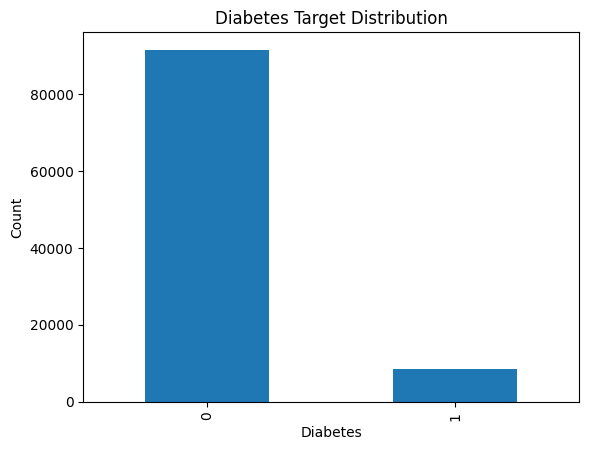

In [43]:
df["diabetes"].value_counts().plot(kind="bar")

plt.title("Diabetes Target Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

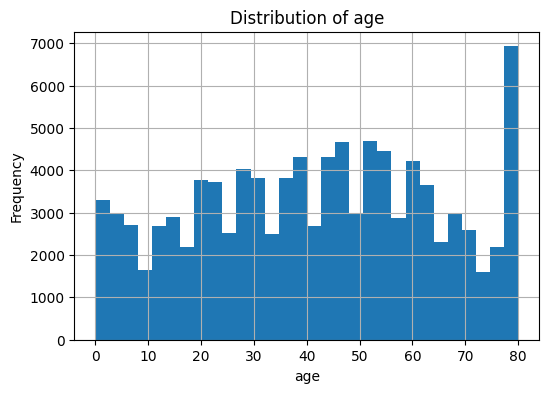

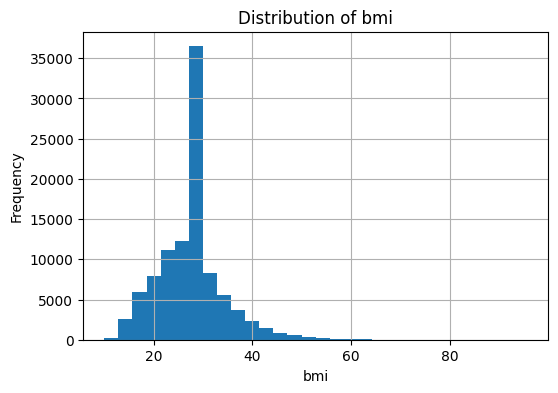

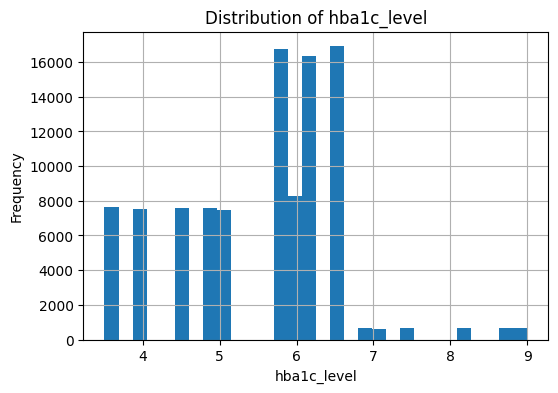

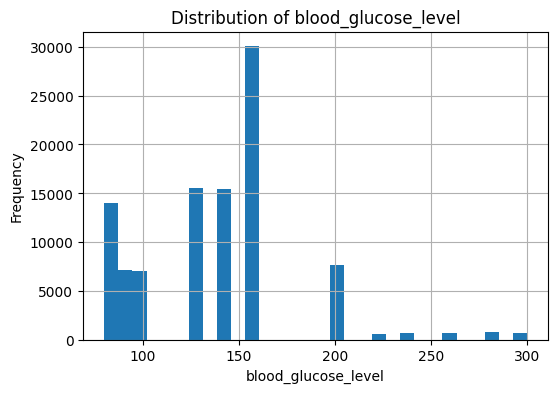

In [44]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

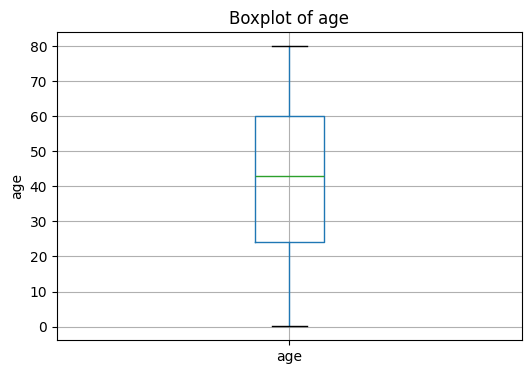

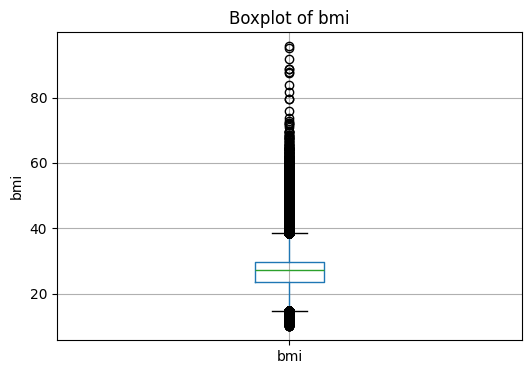

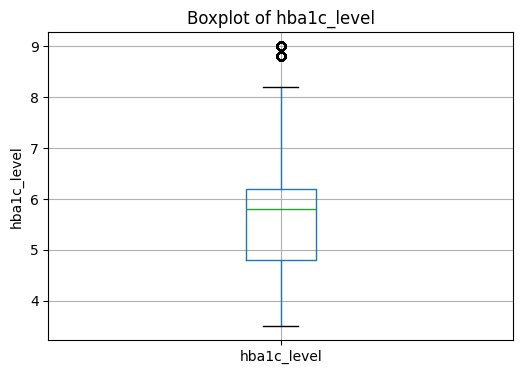

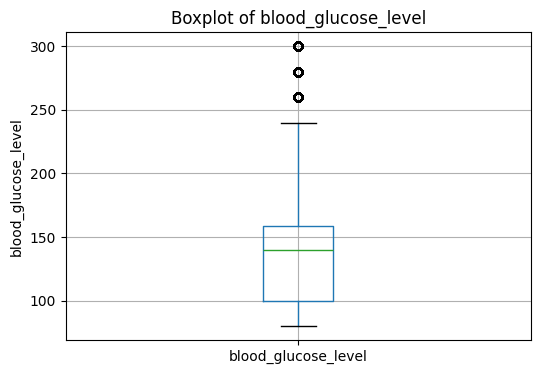

In [45]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

<Figure size 600x400 with 0 Axes>

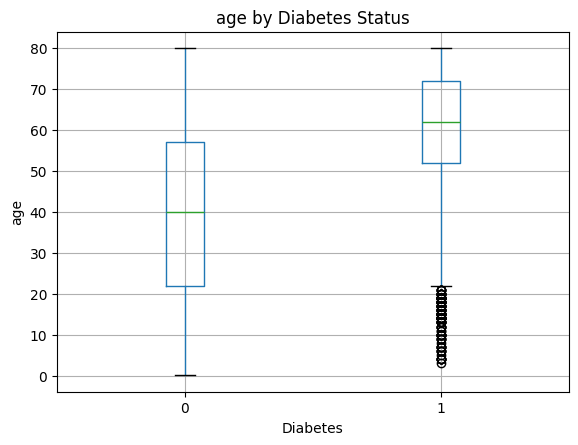

<Figure size 600x400 with 0 Axes>

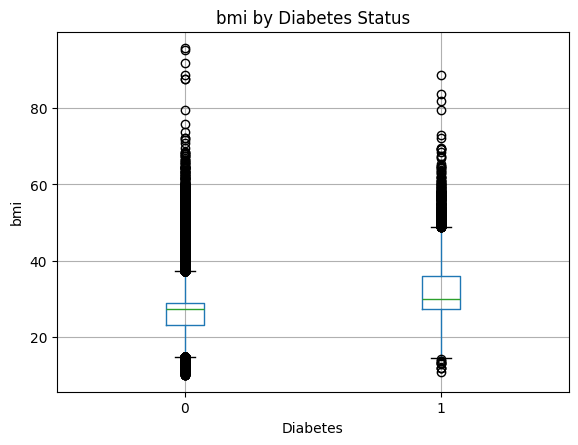

<Figure size 600x400 with 0 Axes>

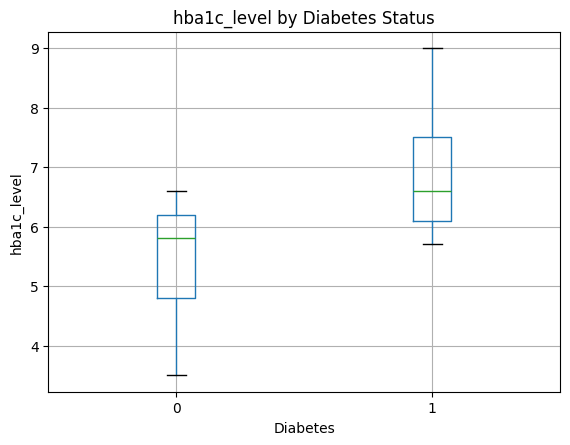

<Figure size 600x400 with 0 Axes>

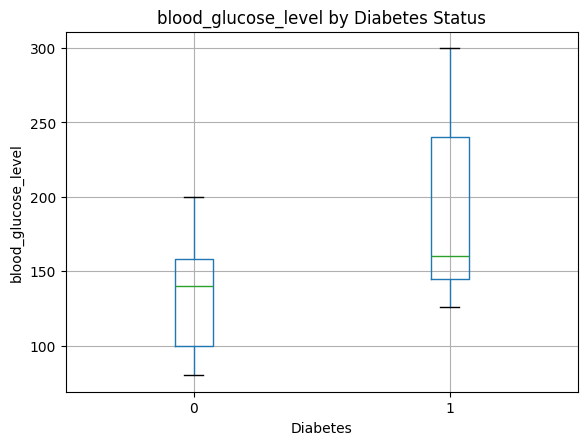

In [46]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col, by="diabetes")
    plt.title(f"{col} by Diabetes Status")
    plt.suptitle("")
    plt.xlabel("Diabetes")
    plt.ylabel(col)
    plt.show()

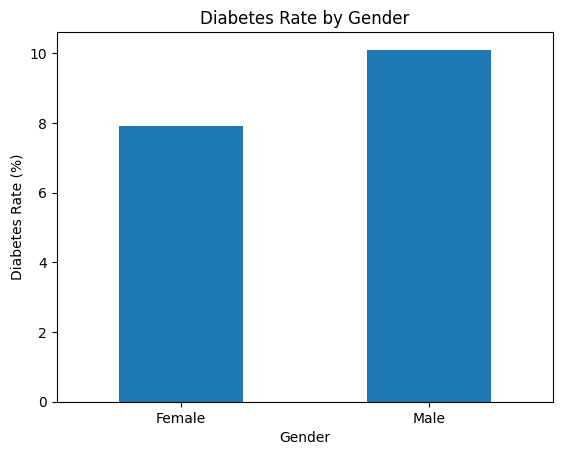

In [47]:
(df_clean.groupby("gender")["diabetes"].mean() * 100).plot(kind="bar")

plt.title("Diabetes Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=0)
plt.show()

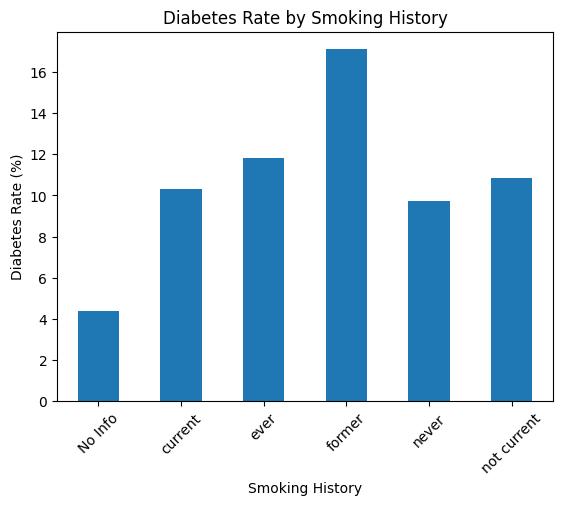

In [48]:
(df_clean.groupby("smoking_history")["diabetes"].mean() * 100).plot(kind="bar")

plt.title("Diabetes Rate by Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=45)
plt.show()

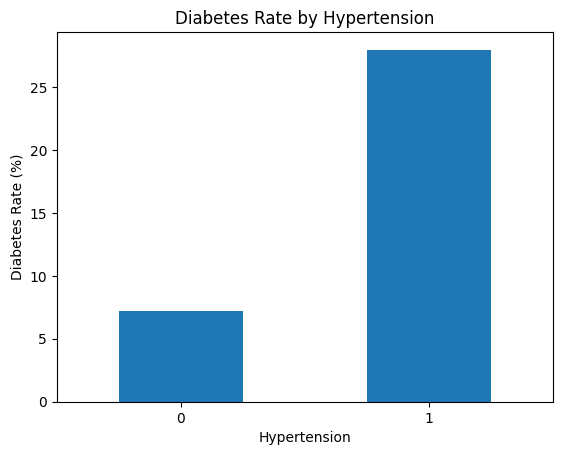

In [49]:
(df_clean.groupby("hypertension")["diabetes"].mean() * 100).plot(kind="bar")

plt.title("Diabetes Rate by Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=0)
plt.show()

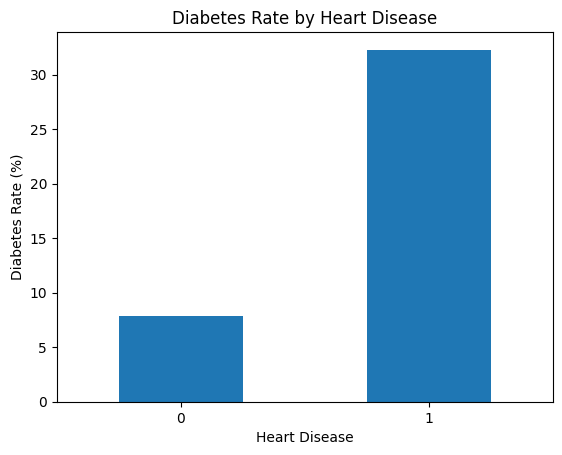

In [50]:
(df_clean.groupby("heart_disease")["diabetes"].mean() * 100).plot(kind="bar")

plt.title("Diabetes Rate by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=0)
plt.show()

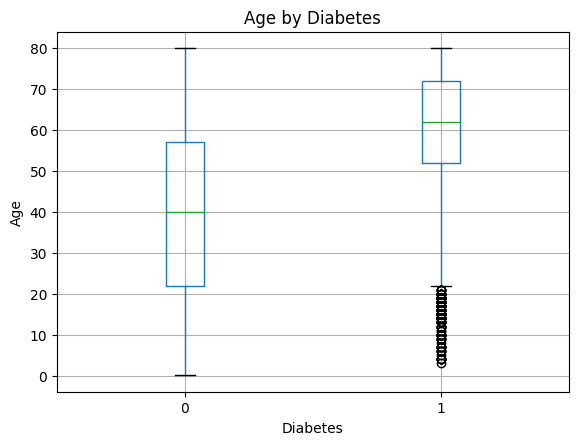

In [51]:
df_clean.boxplot(column="age", by="diabetes")

plt.title("Age by Diabetes")
plt.suptitle("")
plt.xlabel("Diabetes")
plt.ylabel("Age")
plt.show()

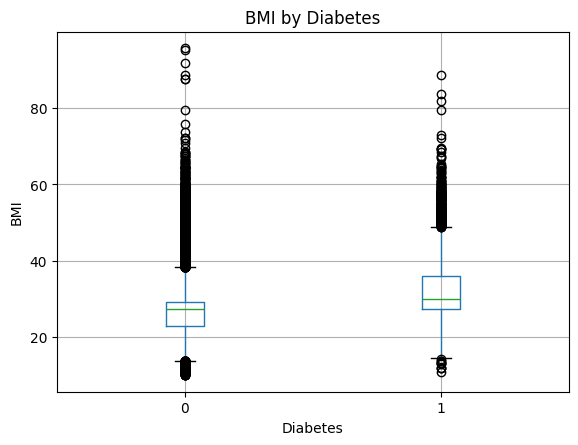

In [52]:
df_clean.boxplot(column="bmi", by="diabetes")

plt.title("BMI by Diabetes")
plt.suptitle("")
plt.xlabel("Diabetes")
plt.ylabel("BMI")
plt.show()

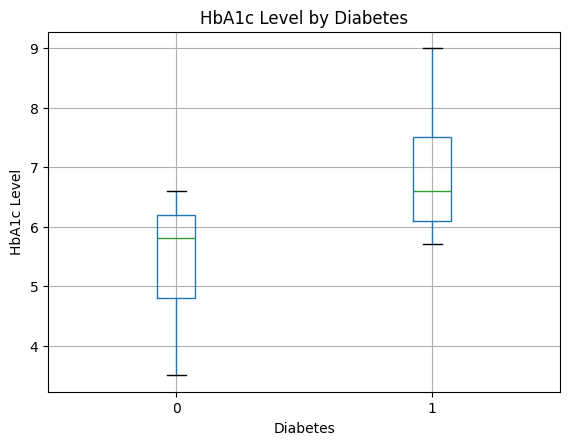

In [53]:
df_clean.boxplot(column="hba1c_level", by="diabetes")

plt.title("HbA1c Level by Diabetes")
plt.suptitle("")
plt.xlabel("Diabetes")
plt.ylabel("HbA1c Level")
plt.show()

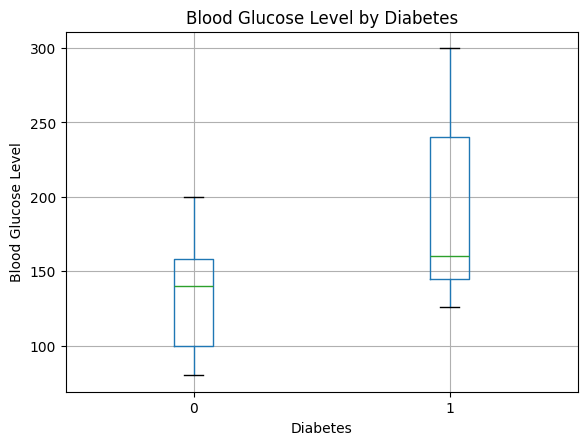

In [54]:
df_clean.boxplot(column="blood_glucose_level", by="diabetes")

plt.title("Blood Glucose Level by Diabetes")
plt.suptitle("")
plt.xlabel("Diabetes")
plt.ylabel("Blood Glucose Level")
plt.show()

In [55]:
corr_matrix = df_clean.corr(numeric_only=True)

corr_matrix

,age,hypertension,heart_disease,bmi,hba1c_level,blood_glucose_level,diabetes
age,1.000000,0.257297,0.238449,0.344779,0.106708,0.114323,0.264918
hypertension,0.257297,1.000000,0.119972,0.148124,0.081443,0.084841,0.195696
heart_disease,0.238449,0.119972,1.000000,0.061382,0.068142,0.070838,0.170701
bmi,0.344779,0.148124,0.061382,1.000000,0.084443,0.092593,0.214951
hba1c_level,0.106708,0.081443,0.068142,0.084443,1.000000,0.171717,0.406446
blood_glucose_level,0.114323,0.084841,0.070838,0.092593,0.171717,1.000000,0.424366
diabetes,0.264918,0.195696,0.170701,0.214951,0.406446,0.424366,1.000000


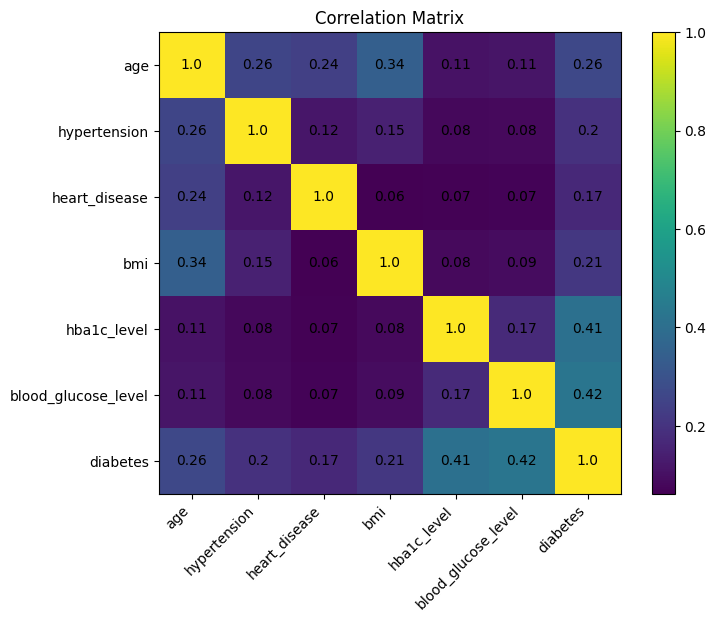

In [56]:
plt.figure(figsize=(8, 6))

plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2), ha="center", va="center")

plt.title("Correlation Matrix")
plt.show()

# **Data Preparation and Processing**



In [57]:
X = df_clean.drop("diabetes", axis=1)
y = df_clean["diabetes"]

In [58]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96128, 8)
y shape: (96128,)


In [59]:
# First split: 80% temporary data, 20% final test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Second split: split the 80% into 60% train and 20% validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

#Because diabetes cases are only around 8.82%. We need to make sure train, validation, and test all have similar diabetes percentages, that is why we use "stratify = y"

In [60]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nTraining target balance:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target balance:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTesting target balance:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (57676, 8)
X_val: (19226, 8)
X_test: (19226, 8)

Training target balance:
diabetes
0    91.176573
1     8.823427
Name: proportion, dtype: float64

Validation target balance:
diabetes
0    91.173411
1     8.826589
Name: proportion, dtype: float64

Testing target balance:
diabetes
0    91.178612
1     8.821388
Name: proportion, dtype: float64


In [61]:
# asemnahom talata 3l4a : feature -> technique  "lw 7d mo3trd yareit yrn 3lya y2oly leh el awl :) "
#   Numeric -> StandardScaler,    Binary -> Pass through ,    Categorical  -> OneHotEncoder

numeric_features = ["age", "bmi", "hba1c_level", "blood_glucose_level"]
binary_features = ["hypertension", "heart_disease"]
categorical_features = ["gender", "smoking_history"]



*   StandardScaler scales numerical columns.
*   OneHotEncoder converts text categories into numbers.
*   ColumnTransformer applies different preprocessing steps to different columns.







In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)

In [63]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [64]:
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)
print("X_test_processed:", X_test_processed.shape)

X_train_processed: (57676, 14)
X_val_processed: (19226, 14)
X_test_processed: (19226, 14)


In [65]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['num__age', 'num__bmi', 'num__hba1c_level',
       'num__blood_glucose_level', 'cat__gender_Female',
       'cat__gender_Male', 'cat__smoking_history_No Info',
       'cat__smoking_history_current', 'cat__smoking_history_ever',
       'cat__smoking_history_former', 'cat__smoking_history_never',
       'cat__smoking_history_not current', 'bin__hypertension',
       'bin__heart_disease'], dtype=object)

In [66]:
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)

X_train_processed_df.head()

,num__age,num__bmi,num__hba1c_level,num__blood_glucose_level,cat__gender_Female,cat__gender_Male,cat__smoking_history_No Info,cat__smoking_history_current,cat__smoking_history_ever,cat__smoking_history_former,cat__smoking_history_never,cat__smoking_history_not current,bin__hypertension,bin__heart_disease
0,-0.033944,-0.635510,0.616541,-1.420859,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.657422,0.340718,3.036457,-0.296760,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.678210,-0.277560,-1.431079,0.534095,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-1.413743,-1.812900,-1.431079,0.167541,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.277623,0.843624,0.616541,-1.298675,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


evaluation function sabta eb2o e3mlolha call w2t el evaluation, ok?

In [67]:
def evaluate_model(model_name, pca_status, y_true, y_pred, print_report=True):
    cm = confusion_matrix(y_true, y_pred)

    tn = cm[0, 0]
    fp = cm[0, 1]
    fn = cm[1, 0]
    tp = cm[1, 1]

    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    if print_report:
        print(f"========== {model_name} | PCA: {pca_status} ==========")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Sensitivity / Recall: {sensitivity:.4f}")
        print(f"F1 Score: {f1:.4f}")

        print("\nConfusion Matrix:")
        print(cm)

        print("\nClassification Report:")
        print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "PCA": pca_status,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "F1 Score": f1
    }

In [68]:
results = []  #empty list el hn store el results feha

# **Models without PCA**

Logistic Regression "Nour"

In [69]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

log_reg_grid = GridSearchCV(
    estimator=log_reg,
    param_grid=log_reg_param_grid,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

log_reg_grid.fit(X_train_processed, y_train)

print("Best parameters:", log_reg_grid.best_params_)
print("Best CV accuracy score:", log_reg_grid.best_score_)
print("\n")

best_log_reg = log_reg_grid.best_estimator_

y_val_pred_log_reg = best_log_reg.predict(X_val_processed)

log_reg_result = evaluate_model(
    model_name="Logistic Regression",
    pca_status="No",
    y_true=y_val,
    y_pred=y_val_pred_log_reg
)
print("\n")

y_test_pred_log_reg = best_log_reg.predict(X_test_processed)

log_reg_result = evaluate_model(
    model_name="Logistic Regression",
    pca_status="No",
    y_true=y_test,
    y_pred=y_test_pred_log_reg
)

results.append(log_reg_result)

Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy score: 0.8875925472514575


========== Logistic Regression | PCA: No ==========
Accuracy: 0.8836
Balanced Accuracy: 0.8808
Precision: 0.4231
Sensitivity / Recall: 0.8774
F1 Score: 0.5709

Confusion Matrix:
[[15499  2030]
 [  208  1489]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17529
           1       0.42      0.88      0.57      1697

    accuracy                           0.88     19226
   macro avg       0.70      0.88      0.75     19226
weighted avg       0.94      0.88      0.90     19226



========== Logistic Regression | PCA: No ==========
Accuracy: 0.8853
Balanced Accuracy: 0.8801
Precision: 0.4267
Sensitivity / Recall: 0.8738
F1 Score: 0.5734

Confusion Matrix:
[[15539  1991]
 [  214  1482]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0

c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


MLP "Abdelrahman"

In [70]:
MLP_pipeline_noPCA = Pipeline([
    ("mlp", MLPClassifier(max_iter=500, random_state=42))
])

MLP_param_grid_noPCA = {
    "mlp__hidden_layer_sizes": [(50,25), (64,32), (100, 50)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [0.0001, 0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.01]
}

MLP_grid_noPCA = GridSearchCV(
    MLP_pipeline_noPCA,
    MLP_param_grid_noPCA,
    cv=5,
    n_jobs=-1,
    scoring="balanced_accuracy"
)
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

MLP_grid_noPCA.fit(X_train_processed, y_train,mlp__sample_weight=sample_weights)

print("Best parameters:", MLP_grid_noPCA.best_params_)
print("Best CV F1 score:", MLP_grid_noPCA.best_score_)
print("\n")

best_MLP_estmator_noPCA=MLP_grid_noPCA.best_estimator_

y_val_pred_best_MLP=best_MLP_estmator_noPCA.predict(X_val_processed)

MLP_eval=evaluate_model(model_name="MLP", pca_status="No",y_true=y_val, y_pred=y_val_pred_best_MLP)

y_test_pred_best_MLP=best_MLP_estmator_noPCA.predict(X_test_processed)

MLP_eval=evaluate_model(model_name="MLP", pca_status="No",y_true=y_test, y_pred=y_test_pred_best_MLP)

results.append(MLP_eval)

Best parameters: {'mlp__activation': 'tanh', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (100, 50), 'mlp__learning_rate_init': 0.01}
Best CV F1 score: 0.9062334709546123


========== MLP | PCA: No ==========
Accuracy: 0.9291
Balanced Accuracy: 0.8959
Precision: 0.5650
Sensitivity / Recall: 0.8556
F1 Score: 0.6806

Confusion Matrix:
[[16411  1118]
 [  245  1452]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     17529
           1       0.56      0.86      0.68      1697

    accuracy                           0.93     19226
   macro avg       0.78      0.90      0.82     19226
weighted avg       0.95      0.93      0.94     19226

========== MLP | PCA: No ==========
Accuracy: 0.9256
Balanced Accuracy: 0.8931
Precision: 0.5504
Sensitivity / Recall: 0.8538
F1 Score: 0.6693

Confusion Matrix:
[[16347  1183]
 [  248  1448]]

Classification Report:
              precision    recall  f1-score   support

         

SVM "Mohamed"

**linear SVM**

In [71]:
linear_svm = SVC(
    kernel="linear",
    C=1,
    class_weight="balanced",
    random_state=42
)

linear_svm.fit(X_train_processed, y_train)

y_val_pred_linear = linear_svm.predict(X_val_processed)
y_test_pred_linear = linear_svm.predict(X_test_processed)

linear_val_results = evaluate_model(
    "Linear SVM Without PCA - Validation",
    "No",
    y_val,
    y_val_pred_linear
)

linear_test_results = evaluate_model(
    "Linear SVM Without PCA - Test",
    "No",
    y_test,
    y_test_pred_linear
)

results.append(linear_test_results)

========== Linear SVM Without PCA - Validation | PCA: No ==========
Accuracy: 0.8824
Balanced Accuracy: 0.8802
Precision: 0.4204
Sensitivity / Recall: 0.8774
F1 Score: 0.5684

Confusion Matrix:
[[15476  2053]
 [  208  1489]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17529
           1       0.42      0.88      0.57      1697

    accuracy                           0.88     19226
   macro avg       0.70      0.88      0.75     19226
weighted avg       0.94      0.88      0.90     19226

========== Linear SVM Without PCA - Test | PCA: No ==========
Accuracy: 0.8855
Balanced Accuracy: 0.8823
Precision: 0.4274
Sensitivity / Recall: 0.8785
F1 Score: 0.5751

Confusion Matrix:
[[15534  1996]
 [  206  1490]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     17530
           1       0.43      0.88      0.58      1696

    accuracy     

In [72]:
#Gussian Kernel

In [73]:
rbf_svm_basic = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

rbf_svm_basic.fit(X_train_processed, y_train)

y_val_pred_rbf_basic = rbf_svm_basic.predict(X_val_processed)
y_test_pred_rbf_basic = rbf_svm_basic.predict(X_test_processed)

rbf_basic_val_results = evaluate_model(
    "RBF SVM Basic Without PCA - Validation",
    "No",
    y_val,
    y_val_pred_rbf_basic
)

rbf_basic_test_results = evaluate_model(
    "RBF SVM Basic Without PCA - Test",
    "No",
    y_test,
    y_test_pred_rbf_basic
)

results.append(rbf_basic_test_results)

========== RBF SVM Basic Without PCA - Validation | PCA: No ==========
Accuracy: 0.8884
Balanced Accuracy: 0.8978
Precision: 0.4365
Sensitivity / Recall: 0.9093
F1 Score: 0.5898

Confusion Matrix:
[[15537  1992]
 [  154  1543]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     17529
           1       0.44      0.91      0.59      1697

    accuracy                           0.89     19226
   macro avg       0.71      0.90      0.76     19226
weighted avg       0.94      0.89      0.90     19226

========== RBF SVM Basic Without PCA - Test | PCA: No ==========
Accuracy: 0.8872
Balanced Accuracy: 0.8977
Precision: 0.4337
Sensitivity / Recall: 0.9104
F1 Score: 0.5875

Confusion Matrix:
[[15514  2016]
 [  152  1544]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17530
           1       0.43      0.91      0.59      1696

    accurac

**grid search**

In [74]:
X_train_tune, _, y_train_tune, _ = train_test_split(
    X_train_processed,
    y_train,
    train_size=10000,
    stratify=y_train,
    random_state=42
)

print("Tuning sample shape:", X_train_tune.shape)
print("Tuning target balance:")

Tuning sample shape: (10000, 14)
Tuning target balance:


In [75]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, "scale"]
}

grid_search = GridSearchCV(
    estimator=SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=42
    ),
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_tune, y_train_tune)

print("Best Grid Search Parameters:")
print(grid_search.best_params_)

print("Best Grid Search CV F1 Score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Grid Search Parameters:
{'C': 1, 'gamma': 'scale'}
Best Grid Search CV F1 Score:
0.9033027414261457


**Gaussian SVM Grid**

In [76]:
best_grid_params = grid_search.best_params_

rbf_svm_grid = SVC(
    kernel="rbf",
    C=best_grid_params["C"],
    gamma=best_grid_params["gamma"],
    class_weight="balanced",
    random_state=42
)

rbf_svm_grid.fit(X_train_processed, y_train)

y_val_pred_grid = rbf_svm_grid.predict(X_val_processed)
y_test_pred_grid = rbf_svm_grid.predict(X_test_processed)

grid_val_results = evaluate_model(
    "RBF SVM Grid Search Without PCA - Validation",
    "No",
    y_val,
    y_val_pred_grid
)

grid_test_results = evaluate_model(
    "RBF SVM Grid Search Without PCA - Test",
    "No",
    y_test,
    y_test_pred_grid
)

results.append(grid_test_results)

========== RBF SVM Grid Search Without PCA - Validation | PCA: No ==========
Accuracy: 0.8884
Balanced Accuracy: 0.8978
Precision: 0.4365
Sensitivity / Recall: 0.9093
F1 Score: 0.5898

Confusion Matrix:
[[15537  1992]
 [  154  1543]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     17529
           1       0.44      0.91      0.59      1697

    accuracy                           0.89     19226
   macro avg       0.71      0.90      0.76     19226
weighted avg       0.94      0.89      0.90     19226

========== RBF SVM Grid Search Without PCA - Test | PCA: No ==========
Accuracy: 0.8872
Balanced Accuracy: 0.8977
Precision: 0.4337
Sensitivity / Recall: 0.9104
F1 Score: 0.5875

Confusion Matrix:
[[15514  2016]
 [  152  1544]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17530
           1       0.43      0.91      0.59      1696


**PSO**

In [77]:
X_pso_train, _, y_pso_train, _ = train_test_split(
    X_train_processed,
    y_train,
    train_size=8000,
    stratify=y_train,
    random_state=42
)

X_pso_val, _, y_pso_val, _ = train_test_split(
    X_val_processed,
    y_val,
    train_size=3000,
    stratify=y_val,
    random_state=42
)

In [78]:

def svm_pso_objective(particles):
    """
    particles shape = (n_particles, 2)
    column 0 = C
    column 1 = gamma
    """
    scores = []

    for particle in particles:
        C = particle[0]
        gamma = particle[1]

        model = SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_pso_train, y_pso_train)
        y_pred = model.predict(X_pso_val)

        f1 = f1_score(y_pso_val, y_pred, zero_division=0)

        # PSO minimizes, so we return 1 - f1
        scores.append(1 - f1)

    return np.array(scores)


In [79]:

lower_bounds = [0.1, 0.0001]
upper_bounds = [100, 1]

bounds = (np.array(lower_bounds), np.array(upper_bounds))


In [80]:
options = {
    "c1": 1.5,
    "c2": 1.5,
    "w": 0.7
}

optimizer = GlobalBestPSO(
    n_particles=8,
    dimensions=2,
    options=options,
    bounds=bounds
)

best_cost, best_position = optimizer.optimize(
    svm_pso_objective,
    iters=8
)

best_pso_C = best_position[0]
best_pso_gamma = best_position[1]

print("Best PSO Cost:", best_cost)
print("Best PSO F1:", 1 - best_cost)
print("Best PSO C:", best_pso_C)
print("Best PSO gamma:", best_pso_gamma)

2026-05-19 21:37:37,611 - pyswarms.single.global_best - INFO - Optimize for 8 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|8/8, best_cost=0.38 
2026-05-19 21:38:15,126 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3800350262697023, best pos: [76.36083425  0.56928986]


Best PSO Cost: 0.3800350262697023
Best PSO F1: 0.6199649737302977
Best PSO C: 76.36083424750571
Best PSO gamma: 0.5692898606803157


**Gaussian SVM PSO**

In [81]:
svm_pso_final = SVC(
    kernel="rbf",
    C=best_pso_C,
    gamma=best_pso_gamma,
    class_weight="balanced",
    random_state=42
)

svm_pso_final.fit(X_train_processed, y_train)

y_val_pred_pso = svm_pso_final.predict(X_val_processed)
y_test_pred_pso = svm_pso_final.predict(X_test_processed)
pso_val_results = evaluate_model(
    "RBF SVM PSO - Validation",
    "No",
    y_val,
    y_val_pred_pso
)

pso_test_results = evaluate_model(
    "RBF SVM PSO - Test",
    "No",
    y_test,
    y_test_pred_pso
)

results.append(pso_test_results)

========== RBF SVM PSO - Validation | PCA: No ==========
Accuracy: 0.9140
Balanced Accuracy: 0.8634
Precision: 0.5080
Sensitivity / Recall: 0.8020
F1 Score: 0.6220

Confusion Matrix:
[[16211  1318]
 [  336  1361]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     17529
           1       0.51      0.80      0.62      1697

    accuracy                           0.91     19226
   macro avg       0.74      0.86      0.79     19226
weighted avg       0.94      0.91      0.92     19226

========== RBF SVM PSO - Test | PCA: No ==========
Accuracy: 0.9105
Balanced Accuracy: 0.8551
Precision: 0.4955
Sensitivity / Recall: 0.7877
F1 Score: 0.6084

Confusion Matrix:
[[16170  1360]
 [  360  1336]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     17530
           1       0.50      0.79      0.61      1696

    accuracy                           

Naive Bayes "Hagar"

In [82]:
nb_param_grid = {'var_smoothing': np.logspace(-12, 0, 25)}

nb_grid = GridSearchCV(
    GaussianNB(), nb_param_grid,
    cv=5, scoring="balanced_accuracy", n_jobs=-1
)
nb_grid.fit(X_train_processed, y_train)

best_vs_no_pca = nb_grid.best_params_['var_smoothing']
print(f'Best var_smoothing : {best_vs_no_pca:.2e}')
print(f'Best CV F1         : {nb_grid.best_score_*100:.2f}%')

Best var_smoothing : 3.16e-02
Best CV F1         : 80.23%


In [83]:
nb_no_pca = GaussianNB(var_smoothing=best_vs_no_pca)
nb_no_pca.fit(X_train_processed, y_train)

y_val_pred_nb = nb_no_pca.predict(X_val_processed)

nb_result = evaluate_model(
    model_name='Naive Bayes',
    pca_status='No',
    y_true=y_val,
    y_pred=y_val_pred_nb
)
results.append(nb_result)

========== Naive Bayes | PCA: No ==========
Accuracy: 0.9267
Balanced Accuracy: 0.8041
Precision: 0.5744
Sensitivity / Recall: 0.6553
F1 Score: 0.6122

Confusion Matrix:
[[16705   824]
 [  585  1112]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     17529
           1       0.57      0.66      0.61      1697

    accuracy                           0.93     19226
   macro avg       0.77      0.80      0.79     19226
weighted avg       0.93      0.93      0.93     19226



Random Forest "Nour"

In [84]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="balanced_accuracy",
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV accuracy score:", rf_grid.best_score_)
print("\n")

best_rf = rf_grid.best_estimator_

y_val_pred_rf = best_rf.predict(X_val_processed)

rf_result = evaluate_model(
    model_name="Random Forest",
    pca_status="No",
    y_true=y_val,
    y_pred=y_val_pred_rf
)
print("\n")
y_test_pred_rf = best_rf.predict(X_test_processed)

rf_result = evaluate_model(
    model_name="Random Forest",
    pca_status="No",
    y_true=y_test,
    y_pred=y_test_pred_rf
)

results.append(rf_result)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy score: 0.9075988044187041


========== Random Forest | PCA: No ==========
Accuracy: 0.9040
Balanced Accuracy: 0.9048
Precision: 0.4769
Sensitivity / Recall: 0.9057
F1 Score: 0.6248

Confusion Matrix:
[[15843  1686]
 [  160  1537]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17529
           1       0.48      0.91      0.62      1697

    accuracy                           0.90     19226
   macro avg       0.73      0.90      0.78     19226
weighted avg       0.94      0.90      0.92     19226



========== Random Forest | PCA: No ==========
Accuracy: 0.9021
Balanced Accuracy: 0.9019
Precision: 0.4713
Sensitivity / Recall: 0.9015
F1 Score: 0.6190

Confusion Matrix:
[[15815  1715]
 [  167  1529]]

Classification Report:
              precision    recall  f1-score   support

           0  

Gradient Boosting "Ahmed"

In [85]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    scoring="balanced_accuracy",
    cv=3,
    n_jobs=-1
)

gb_grid.fit(X_train_processed, y_train)

print("Best parameters:", gb_grid.best_params_)
print("Best CV Balanced Accuracy:", gb_grid.best_score_)
print("\n")

best_gb = gb_grid.best_estimator_

y_val_pred_gb = best_gb.predict(X_val_processed)

gb_result = evaluate_model(
    model_name="Gradient Boosting",
    pca_status="No",
    y_true=y_val,
    y_pred=y_val_pred_gb
)

print("\n")

y_test_pred_gb = best_gb.predict(X_test_processed)

gb_result = evaluate_model(
    model_name="Gradient Boosting",
    pca_status="No",
    y_true=y_test,
    y_pred=y_test_pred_gb
)

results.append(gb_result)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV Balanced Accuracy: 0.8449118436655759


========== Gradient Boosting | PCA: No ==========
Accuracy: 0.9696
Balanced Accuracy: 0.8418
Precision: 0.9573
Sensitivity / Recall: 0.6865
F1 Score: 0.7996

Confusion Matrix:
[[17477    52]
 [  532  1165]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17529
           1       0.96      0.69      0.80      1697

    accuracy                           0.97     19226
   macro avg       0.96      0.84      0.89     19226
weighted avg       0.97      0.97      0.97     19226



========== Gradient Boosting | PCA: No ==========
Accuracy: 0.9701
Balanced Accuracy: 0.8484
Precision: 0.9474
Sensitivity / Recall: 0.7005
F1 Score: 0.8054

Confusion Matrix:
[[17464    66]
 [  508  1188]]

Classification Report:
              precision    recall  f1-score   support

           

Adaboosting "Abdelrahman"

In [86]:
base_tree = DecisionTreeClassifier(
    random_state=42
)

ada_model = AdaBoostClassifier(
    estimator=base_tree,
    random_state=42
)

ada_param_grid = {
    'n_estimators': [25, 50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'estimator__max_depth': [1, 2, 3],
    'estimator__min_samples_split': [2, 5, 10]
}

ada_grid_search = GridSearchCV(
    estimator=ada_model,
    param_grid=ada_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=2
)

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

ada_grid_search.fit(X_train_processed, y_train,sample_weight=sample_weights)

print("Best parameters:", ada_grid_search.best_params_)
print("Best CV F1 score:", ada_grid_search.best_score_)
print("\n")

best_ada_estmator_noPCA=ada_grid_search.best_estimator_

y_val_pred_best_ada=best_ada_estmator_noPCA.predict(X_val_processed)

ada_eval=evaluate_model(model_name="Adaboost", pca_status="No",y_true=y_val, y_pred=y_val_pred_best_ada)

y_test_pred_best_ada=best_ada_estmator_noPCA.predict(X_test_processed)

ada_eval=evaluate_model(model_name="Adaboost", pca_status="No",y_true=y_test, y_pred=y_test_pred_best_ada)

results.append(ada_eval)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters: {'estimator__max_depth': 3, 'estimator__min_samples_split': 2, 'learning_rate': 1.0, 'n_estimators': 100}
Best CV F1 score: 0.9143579183438899


========== Adaboost | PCA: No ==========
Accuracy: 0.9034
Balanced Accuracy: 0.9079
Precision: 0.4755
Sensitivity / Recall: 0.9134
F1 Score: 0.6254

Confusion Matrix:
[[15819  1710]
 [  147  1550]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17529
           1       0.48      0.91      0.63      1697

    accuracy                           0.90     19226
   macro avg       0.73      0.91      0.78     19226
weighted avg       0.95      0.90      0.92     19226

========== Adaboost | PCA: No ==========
Accuracy: 0.9022
Balanced Accuracy: 0.9046
Precision: 0.4718
Sensitivity / Recall: 0.9074
F1 Score: 0.6208

Confusion Matrix:
[[15807  1723]
 [  157  1539]]

Classification Report:
    

XGBoosting "Hagar"

In [87]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = neg / pos

xgb_param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
}

xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss', random_state=42, use_label_encoder=False), xgb_param_grid,
    cv=5, scoring="balanced_accuracy", n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train_processed, y_train)

best_xgb_no_pca = xgb_grid.best_estimator_
print(f'Best params : {best_xgb_no_pca}')
print(f'Best CV F1  : {xgb_grid.best_score_*100:.2f}%')

y_test_pred_xgb=best_xgb_no_pca.predict(X_test_processed)
xgb_eval=evaluate_model(model_name="XGBoosting", pca_status="No",y_true=y_test, y_pred=y_test_pred_xgb)

results.append(xgb_eval)


Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:43:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)
Best CV F1  : 91.44%
========== XGBoosting | PCA: No ==========
Accuracy: 0.9021
Balanced Accuracy: 0.9085
Precision: 0.4718
Sensitivity / Recall: 0.9163
F1 Score: 0.6228

Confusion Matrix:
[[15790  1740]
 [  1

In [88]:
xgb_no_pca = XGBClassifier(
    xgb_model = best_xgb_no_pca,
    scale_pos_weight=scale_weight,
    class_weight="balanced",
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)
xgb_no_pca.fit(
    X_train_processed, y_train,
    eval_set=[(X_train_processed, y_train), (X_val_processed, y_val)],
    verbose=False
)

y_val_pred_xgb = xgb_no_pca.predict(X_val_processed)

xgb_result = evaluate_model(
    model_name='XGBoosting',
    pca_status='No',
    y_true=y_val,
    y_pred=y_val_pred_xgb
)
results.append(xgb_result)

========== XGBoosting | PCA: No ==========
Accuracy: 0.9214
Balanced Accuracy: 0.8933
Precision: 0.5341
Sensitivity / Recall: 0.8592
F1 Score: 0.6587

Confusion Matrix:
[[16257  1272]
 [  239  1458]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     17529
           1       0.53      0.86      0.66      1697

    accuracy                           0.92     19226
   macro avg       0.76      0.89      0.81     19226
weighted avg       0.95      0.92      0.93     19226



c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:43:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder", "xgb_model" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# **Models With PCA**

PCA only works after converting all data into numeric form.

In [89]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_processed)
X_val_pca = pca.transform(X_val_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original number of features:", X_train_processed.shape[1])
print("Number of PCA components:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_.sum())

Original number of features: 14
Number of PCA components: 8
Explained variance ratio: 0.9585647654495686


Logistic Regression "Nour"

In [90]:
log_reg_pca = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg_pca_grid = GridSearchCV(
    estimator=log_reg_pca,
    param_grid=log_reg_param_grid,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

log_reg_pca_grid.fit(X_train_pca, y_train)

print("Best parameters with PCA:", log_reg_pca_grid.best_params_)
print("Best CV accuracy score with PCA:", log_reg_pca_grid.best_score_)
print("\n")

best_log_reg_pca = log_reg_pca_grid.best_estimator_

y_val_pred_log_reg_pca = best_log_reg_pca.predict(X_val_pca)

log_reg_pca_result = evaluate_model(
    model_name="Logistic Regression",
    pca_status="Yes",
    y_true=y_val,
    y_pred=y_val_pred_log_reg_pca
)
print("\n")
y_test_pred_log_reg_pca = best_log_reg_pca.predict(X_test_pca)

log_reg_pca_result = evaluate_model(
    model_name="Logistic Regression",
    pca_status="Yes",
    y_true=y_test,
    y_pred=y_test_pred_log_reg_pca
)

results.append(log_reg_pca_result)

Best parameters with PCA: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy score with PCA: 0.8836974384506128


========== Logistic Regression | PCA: Yes ==========
Accuracy: 0.8814
Balanced Accuracy: 0.8804
Precision: 0.4182
Sensitivity / Recall: 0.8792
F1 Score: 0.5668

Confusion Matrix:
[[15453  2076]
 [  205  1492]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17529
           1       0.42      0.88      0.57      1697

    accuracy                           0.88     19226
   macro avg       0.70      0.88      0.75     19226
weighted avg       0.94      0.88      0.90     19226



========== Logistic Regression | PCA: Yes ==========
Accuracy: 0.8832
Balanced Accuracy: 0.8795
Precision: 0.4218
Sensitivity / Recall: 0.8750
F1 Score: 0.5692

Confusion Matrix:
[[15496  2034]
 [  212  1484]]

Classification Report:
              precision    recall  f1-score   support

           0       0

c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


MLP "Abdelrahman"

In [91]:
MLP_pipeline_noPCA = Pipeline([
    ("mlp", MLPClassifier(max_iter=500, random_state=42))
])

MLP_param_grid_noPCA = {
    "mlp__hidden_layer_sizes": [(50,25), (64,32), (100, 50)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [0.0001, 0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.01]
}

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

MLP_grid_withPCA = GridSearchCV(
    MLP_pipeline_noPCA,
    MLP_param_grid_noPCA,
    cv=5,
    n_jobs=-1,
    scoring="balanced_accuracy"
)

MLP_grid_withPCA.fit(X_train_pca, y_train,mlp__sample_weight=sample_weights)

print("Best parameters:", MLP_grid_withPCA.best_params_)
print("Best CV accuracy score:", MLP_grid_withPCA.best_score_)
print("\n")

best_MLP_estmator_withPCA=MLP_grid_withPCA.best_estimator_

y_val_pred_best_MLP_pca=best_MLP_estmator_withPCA.predict(X_val_pca)

MLP_eval_pca=evaluate_model(model_name="MLP", pca_status="yes",y_true=y_val, y_pred=y_val_pred_best_MLP_pca)

y_test_pred_best_MLP_pca=best_MLP_estmator_withPCA.predict(X_test_pca)

MLP_eval_pca=evaluate_model(model_name="MLP", pca_status="yes",y_true=y_test, y_pred=y_test_pred_best_MLP_pca)

results.append(MLP_eval_pca)

Best parameters: {'mlp__activation': 'tanh', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (50, 25), 'mlp__learning_rate_init': 0.001}
Best CV accuracy score: 0.9057682013693018


========== MLP | PCA: yes ==========
Accuracy: 0.8961
Balanced Accuracy: 0.9015
Precision: 0.4556
Sensitivity / Recall: 0.9081
F1 Score: 0.6068

Confusion Matrix:
[[15688  1841]
 [  156  1541]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     17529
           1       0.46      0.91      0.61      1697

    accuracy                           0.90     19226
   macro avg       0.72      0.90      0.77     19226
weighted avg       0.94      0.90      0.91     19226

========== MLP | PCA: yes ==========
Accuracy: 0.8959
Balanced Accuracy: 0.8968
Precision: 0.4544
Sensitivity / Recall: 0.8980
F1 Score: 0.6034

Confusion Matrix:
[[15701  1829]
 [  173  1523]]

Classification Report:
              precision    recall  f1-score   support

 

SVM "Mohamed"

**linear SVM**

In [92]:
linear_svm_pca = SVC(
    kernel="linear",
    C=1,
    class_weight="balanced",
    random_state=42
)

linear_svm_pca.fit(X_train_pca, y_train)
y_val_pred_linear_pca = linear_svm_pca.predict(X_val_pca)
y_test_pred_linear_pca = linear_svm_pca.predict(X_test_pca)


linear_pca_results = evaluate_model(
    "Linear SVM With PCA - Test",
    "Yes",
    y_test,
    y_test_pred_linear_pca
)

results.append(linear_pca_results)

========== Linear SVM With PCA - Test | PCA: Yes ==========
Accuracy: 0.8804
Balanced Accuracy: 0.8798
Precision: 0.4159
Sensitivity / Recall: 0.8791
F1 Score: 0.5647

Confusion Matrix:
[[15436  2094]
 [  205  1491]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17530
           1       0.42      0.88      0.56      1696

    accuracy                           0.88     19226
   macro avg       0.70      0.88      0.75     19226
weighted avg       0.94      0.88      0.90     19226



**PSO+PCA**

In [93]:
X_pso_train_pca, _, y_pso_train_pca, _ = train_test_split(
    X_train_pca,
    y_train,
    train_size=8000,
    stratify=y_train,
    random_state=42
)

X_pso_val_pca, _, y_pso_val_pca, _ = train_test_split(
    X_val_pca,
    y_val,
    train_size=3000,
    stratify=y_val,
    random_state=42
)

In [94]:
def svm_pso_objective_pca(particles):
    scores = []

    for particle in particles:
        C = particle[0]
        gamma = particle[1]

        model = SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_pso_train_pca, y_pso_train_pca)
        y_pred = model.predict(X_pso_val_pca)

        f1 = f1_score(y_pso_val_pca, y_pred, zero_division=0)
        scores.append(1 - f1)

    return np.array(scores)

In [95]:
lower_bounds = np.array([0.1, 0.0001])
upper_bounds = np.array([100, 1])

bounds = (lower_bounds, upper_bounds)

options = {
    "c1": 1.5,
    "c2": 1.5,
    "w": 0.7
}

optimizer_pca = GlobalBestPSO(
    n_particles=8,
    dimensions=2,
    options=options,
    bounds=bounds
)

best_cost_pca, best_position_pca = optimizer_pca.optimize(
    svm_pso_objective_pca,
    iters=8
)

best_pso_C_pca = best_position_pca[0]
best_pso_gamma_pca = best_position_pca[1]

print("Best PSO (PCA) Cost:", best_cost_pca)
print("Best PSO (PCA) F1:", 1 - best_cost_pca)
print("Best C (PCA):", best_pso_C_pca)
print("Best gamma (PCA):", best_pso_gamma_pca)

2026-05-19 21:47:31,026 - pyswarms.single.global_best - INFO - Optimize for 8 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|8/8, best_cost=0.387
2026-05-19 21:48:17,460 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.38749999999999996, best pos: [7.32690742 0.93149102]


Best PSO (PCA) Cost: 0.38749999999999996
Best PSO (PCA) F1: 0.6125
Best C (PCA): 7.326907419749179
Best gamma (PCA): 0.9314910163679542


In [96]:
svm_pso_pca_final = SVC(
    kernel="rbf",
    C=best_pso_C_pca,
    gamma=best_pso_gamma_pca,
    class_weight="balanced",
    random_state=42
)

svm_pso_pca_final.fit(X_train_pca, y_train)

y_val_pred_pso_pca = svm_pso_pca_final.predict(X_val_pca)
y_test_pred_pso_pca = svm_pso_pca_final.predict(X_test_pca)
pso_pca_val_results = evaluate_model(
    "RBF SVM PSO With PCA - Validation",
    "Yes",
    y_val,
    y_val_pred_pso_pca
)

pso_pca_test_results = evaluate_model(
    "RBF SVM PSO With PCA - Test",
    "Yes",
    y_test,
    y_test_pred_pso_pca
)

results.append(pso_pca_test_results)

========== RBF SVM PSO With PCA - Validation | PCA: Yes ==========
Accuracy: 0.8957
Balanced Accuracy: 0.8882
Precision: 0.4531
Sensitivity / Recall: 0.8792
F1 Score: 0.5980

Confusion Matrix:
[[15728  1801]
 [  205  1492]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17529
           1       0.45      0.88      0.60      1697

    accuracy                           0.90     19226
   macro avg       0.72      0.89      0.77     19226
weighted avg       0.94      0.90      0.91     19226

========== RBF SVM PSO With PCA - Test | PCA: Yes ==========
Accuracy: 0.8931
Balanced Accuracy: 0.8814
Precision: 0.4455
Sensitivity / Recall: 0.8673
F1 Score: 0.5886

Confusion Matrix:
[[15699  1831]
 [  225  1471]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17530
           1       0.45      0.87      0.59      1696

    accuracy       

**Gaussian SVM**

In [97]:
rbf_svm_pca = SVC(
    kernel="rbf",
    C=best_grid_params["C"],
    gamma=best_grid_params["gamma"],
    class_weight="balanced",
    random_state=42
)

rbf_svm_pca.fit(X_train_pca, y_train)
y_val_pred_rbf_pca=rbf_svm_pca.predict(X_val_pca)
y_test_pred_rbf_pca = rbf_svm_pca.predict(X_test_pca)

rbf_pca_results = evaluate_model(
    "RBF SVM Grid Search With PCA - Test",
    "Yes",
    y_test,
    y_test_pred_rbf_pca
)

results.append(rbf_pca_results)

========== RBF SVM Grid Search With PCA - Test | PCA: Yes ==========
Accuracy: 0.8787
Balanced Accuracy: 0.8951
Precision: 0.4149
Sensitivity / Recall: 0.9151
F1 Score: 0.5709

Confusion Matrix:
[[15341  2189]
 [  144  1552]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17530
           1       0.41      0.92      0.57      1696

    accuracy                           0.88     19226
   macro avg       0.70      0.90      0.75     19226
weighted avg       0.94      0.88      0.90     19226



Naive Bayes "Hagar"

In [98]:
nb_grid_pca = GridSearchCV(
    GaussianNB(), nb_param_grid,
    cv=5, scoring="balanced_accuracy", n_jobs=-1
)
nb_grid_pca.fit(X_train_pca, y_train)

best_vs_pca = nb_grid_pca.best_params_['var_smoothing']
print(f'Best var_smoothing : {best_vs_pca:.2e}')
print(f'Best CV F1         : {nb_grid_pca.best_score_*100:.2f}%')

Best var_smoothing : 3.16e-05
Best CV F1         : 77.39%


In [99]:
nb_with_pca = GaussianNB(var_smoothing=best_vs_pca)
nb_with_pca.fit(X_train_pca, y_train)

y_val_pred_nb_pca = nb_with_pca.predict(X_val_pca)

nb_pca_result = evaluate_model(
    model_name='Naive Bayes',
    pca_status='Yes',
    y_true=y_val,
    y_pred=y_val_pred_nb_pca
)
results.append(nb_pca_result)

========== Naive Bayes | PCA: Yes ==========
Accuracy: 0.9504
Balanced Accuracy: 0.7639
Precision: 0.8437
Sensitivity / Recall: 0.5374
F1 Score: 0.6566

Confusion Matrix:
[[17360   169]
 [  785   912]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     17529
           1       0.84      0.54      0.66      1697

    accuracy                           0.95     19226
   macro avg       0.90      0.76      0.81     19226
weighted avg       0.95      0.95      0.95     19226



Random Forest "Nour"

In [100]:
rf_pca = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pca_grid = GridSearchCV(
    estimator=rf_pca,
    param_grid=rf_param_grid,
    scoring="balanced_accuracy",
    cv=3,
    n_jobs=-1
)

rf_pca_grid.fit(X_train_pca, y_train)

print("Best parameters with PCA:", rf_pca_grid.best_params_)
print("Best CV accuracy score with PCA:", rf_pca_grid.best_score_)
print("\n")

best_rf_pca = rf_pca_grid.best_estimator_

y_val_pred_rf_pca = best_rf_pca.predict(X_val_pca)

rf_pca_result = evaluate_model(
    model_name="Random Forest",
    pca_status="Yes",
    y_true=y_val,
    y_pred=y_val_pred_rf_pca
)
print("\n")
y_test_pred_rf_pca = best_rf_pca.predict(X_test_pca)

rf_pca_result = evaluate_model(
    model_name="Random Forest",
    pca_status="Yes",
    y_true=y_test,
    y_pred=y_test_pred_rf_pca
)

results.append(rf_pca_result)

Best parameters with PCA: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy score with PCA: 0.8893052745400188


========== Random Forest | PCA: Yes ==========
Accuracy: 0.9032
Balanced Accuracy: 0.8844
Precision: 0.4734
Sensitivity / Recall: 0.8615
F1 Score: 0.6111

Confusion Matrix:
[[15903  1626]
 [  235  1462]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.94     17529
           1       0.47      0.86      0.61      1697

    accuracy                           0.90     19226
   macro avg       0.73      0.88      0.78     19226
weighted avg       0.94      0.90      0.92     19226



========== Random Forest | PCA: Yes ==========
Accuracy: 0.9040
Balanced Accuracy: 0.8869
Precision: 0.4759
Sensitivity / Recall: 0.8662
F1 Score: 0.6143

Confusion Matrix:
[[15912  1618]
 [  227  1469]]

Classification Report:
              precision    recall  f1-score   sup

Gradient Boosting "Ahmed"

In [101]:
gb_pca = GradientBoostingClassifier(
    random_state=42
)

gb_pca_grid = GridSearchCV(
    estimator=gb_pca,
    param_grid=gb_param_grid,
    scoring="balanced_accuracy",
    cv=3,
    n_jobs=-1
)

gb_pca_grid.fit(X_train_pca, y_train)

print("Best parameters with PCA:", gb_pca_grid.best_params_)
print("Best CV Balanced Accuracy with PCA:", gb_pca_grid.best_score_)
print("\n")

best_gb_pca = gb_pca_grid.best_estimator_

y_val_pred_gb_pca = best_gb_pca.predict(X_val_pca)

gb_pca_result = evaluate_model(
    model_name="Gradient Boosting",
    pca_status="Yes",
    y_true=y_val,
    y_pred=y_val_pred_gb_pca
)

print("\n")

y_test_pred_gb_pca = best_gb_pca.predict(X_test_pca)

gb_pca_result = evaluate_model(
    model_name="Gradient Boosting",
    pca_status="Yes",
    y_true=y_test,
    y_pred=y_test_pred_gb_pca
)

results.append(gb_pca_result)

Best parameters with PCA: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV Balanced Accuracy with PCA: 0.8315557020304095


========== Gradient Boosting | PCA: Yes ==========
Accuracy: 0.9660
Balanced Accuracy: 0.8275
Precision: 0.9364
Sensitivity / Recall: 0.6594
F1 Score: 0.7739

Confusion Matrix:
[[17453    76]
 [  578  1119]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17529
           1       0.94      0.66      0.77      1697

    accuracy                           0.97     19226
   macro avg       0.95      0.83      0.88     19226
weighted avg       0.97      0.97      0.96     19226



========== Gradient Boosting | PCA: Yes ==========
Accuracy: 0.9677
Balanced Accuracy: 0.8369
Precision: 0.9388
Sensitivity / Recall: 0.6781
F1 Score: 0.7874

Confusion Matrix:
[[17455    75]
 [  546  1150]]

Classification Report:
              precision    recall  f1-score   

Adaboosting "Abdelrahman"

In [102]:
base_tree = DecisionTreeClassifier(
    random_state=42
)

ada_model = AdaBoostClassifier(
    estimator=base_tree,
    random_state=42
)

ada_param_grid = {
    'n_estimators': [25, 50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'estimator__max_depth': [1, 2, 3],
    'estimator__min_samples_split': [2, 5, 10]
}

ada_grid_search = GridSearchCV(
    estimator=ada_model,
    param_grid=ada_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=2
)

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

ada_grid_search.fit(X_train_pca, y_train,sample_weight=sample_weights)

print("Best parameters:", ada_grid_search.best_params_)
print("Best CV accuracy score:", ada_grid_search.best_score_)
print("\n")

best_ada_estmator_withPCA=ada_grid_search.best_estimator_

y_val_pred_best_ada_pca=best_ada_estmator_withPCA.predict(X_val_pca)

ada_eval_pca=evaluate_model(model_name="Adaboost", pca_status="yes",y_true=y_val, y_pred=y_val_pred_best_ada_pca)

y_test_pred_best_ada_pca=best_ada_estmator_withPCA.predict(X_test_pca)

ada_eval_pca=evaluate_model(model_name="Adaboost", pca_status="yes",y_true=y_test, y_pred=y_test_pred_best_ada_pca)

results.append(ada_eval_pca)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


Best parameters: {'estimator__max_depth': 3, 'estimator__min_samples_split': 10, 'learning_rate': 1.0, 'n_estimators': 200}
Best CV accuracy score: 0.8982421204705435


========== Adaboost | PCA: yes ==========
Accuracy: 0.8919
Balanced Accuracy: 0.8958
Precision: 0.4446
Sensitivity / Recall: 0.9004
F1 Score: 0.5952

Confusion Matrix:
[[15620  1909]
 [  169  1528]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     17529
           1       0.44      0.90      0.60      1697

    accuracy                           0.89     19226
   macro avg       0.72      0.90      0.77     19226
weighted avg       0.94      0.89      0.91     19226

========== Adaboost | PCA: yes ==========
Accuracy: 0.8907
Balanced Accuracy: 0.8900
Precision: 0.4408
Sensitivity / Recall: 0.8892
F1 Score: 0.5894

Confusion Matrix:
[[15617  1913]
 [  188  1508]]

Classification Report:
              precision    recall  f1-score   support

   

XGBoosting "Hagar"

In [103]:
xgb_grid_pca = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss',
                  random_state=42, use_label_encoder=False),
    xgb_param_grid,
    cv=5, scoring="balanced_accuracy", n_jobs=-1, verbose=1
)
xgb_grid_pca.fit(X_train_pca, y_train)

best_xgb_pca = xgb_grid_pca.best_params_
print(f'Best params : {best_xgb_pca}')
print(f'Best CV F1  : {xgb_grid_pca.best_score_*100:.2f}%')

Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:56:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best CV F1  : 90.29%


In [104]:
xgb_with_pca = XGBClassifier(
    **best_xgb_pca,
    scale_pos_weight=scale_weight,
    class_weight="balanced",
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)
xgb_with_pca.fit(
    X_train_pca, y_train,
    eval_set=[(X_train_pca, y_train), (X_val_pca, y_val)],
    verbose=False
)

y_val_pred_xgb_pca = xgb_with_pca.predict(X_val_pca)

xgb_pca_result = evaluate_model(
    model_name='XGBoosting',
    pca_status='Yes',
    y_true=y_val,
    y_pred=y_val_pred_xgb_pca
)
results.append(xgb_pca_result)

c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:56:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========== XGBoosting | PCA: Yes ==========
Accuracy: 0.8936
Balanced Accuracy: 0.8977
Precision: 0.4489
Sensitivity / Recall: 0.9028
F1 Score: 0.5996

Confusion Matrix:
[[15648  1881]
 [  165  1532]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     17529
           1       0.45      0.90      0.60      1697

    accuracy                           0.89     19226
   macro avg       0.72      0.90      0.77     19226
weighted avg       0.94      0.89      0.91     19226



# **Evaluation Metrics**

In [105]:
results_df = pd.DataFrame(results)

results_df

,Model,PCA,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Sensitivity,F1 Score
0,Logistic Regression,No,15539,1991,214,1482,0.885312,0.880122,0.426720,0.873821,0.573418
1,MLP,No,16347,1183,248,1448,0.925570,0.893145,0.550361,0.853774,0.669286
2,Linear SVM Without PCA - Test,No,15534,1996,206,1490,0.885468,0.882338,0.427424,0.878538,0.575068
3,RBF SVM Basic Without PCA - Test,No,15514,2016,152,1544,0.887236,0.897687,0.433708,0.910377,0.587519
4,RBF SVM Grid Search Without PCA - Test,No,15514,2016,152,1544,0.887236,0.897687,0.433708,0.910377,0.587519
5,RBF SVM PSO - Test,No,16170,1360,360,1336,0.910538,0.855077,0.495549,0.787736,0.608379
6,Naive Bayes,No,16705,824,585,1112,0.926714,0.804133,0.574380,0.655274,0.612166
7,Random Forest,No,15815,1715,167,1529,0.902112,0.901850,0.471332,0.901533,0.619028
8,Gradient Boosting,No,17464,66,508,1188,0.970145,0.848353,0.947368,0.700472,0.805424
9,Adaboost,No,15807,1723,157,1539,0.902216,0.904570,0.471796,0.907429,0.620815


In [106]:
results_df.sort_values(by="Balanced Accuracy", ascending=False)

,Model,PCA,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Sensitivity,F1 Score
10,XGBoosting,No,15790,1740,142,1554,0.902112,0.908508,0.471767,0.916274,0.622846
9,Adaboost,No,15807,1723,157,1539,0.902216,0.904570,0.471796,0.907429,0.620815
7,Random Forest,No,15815,1715,167,1529,0.902112,0.901850,0.471332,0.901533,0.619028
21,XGBoosting,Yes,15648,1881,165,1532,0.893582,0.897731,0.448872,0.902770,0.599609
4,RBF SVM Grid Search Without PCA - Test,No,15514,2016,152,1544,0.887236,0.897687,0.433708,0.910377,0.587519
3,RBF SVM Basic Without PCA - Test,No,15514,2016,152,1544,0.887236,0.897687,0.433708,0.910377,0.587519
13,MLP,yes,15701,1829,173,1523,0.895870,0.896830,0.454356,0.897995,0.603407
16,RBF SVM Grid Search With PCA - Test,Yes,15341,2189,144,1552,0.878654,0.895111,0.414862,0.915094,0.570903
11,XGBoosting,No,16257,1272,239,1458,0.921409,0.893299,0.534066,0.859163,0.658685
1,MLP,No,16347,1183,248,1448,0.925570,0.893145,0.550361,0.853774,0.669286


In [107]:
results_df["Model Version"] = results_df["Model"] + " | PCA: " + results_df["PCA"]

results_df

,Model,PCA,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Sensitivity,F1 Score,Model Version
0,Logistic Regression,No,15539,1991,214,1482,0.885312,0.880122,0.426720,0.873821,0.573418,Logistic Regression | PCA: No
1,MLP,No,16347,1183,248,1448,0.925570,0.893145,0.550361,0.853774,0.669286,MLP | PCA: No
2,Linear SVM Without PCA - Test,No,15534,1996,206,1490,0.885468,0.882338,0.427424,0.878538,0.575068,Linear SVM Without PCA - Test | PCA: No
3,RBF SVM Basic Without PCA - Test,No,15514,2016,152,1544,0.887236,0.897687,0.433708,0.910377,0.587519,RBF SVM Basic Without PCA - Test | PCA: No
4,RBF SVM Grid Search Without PCA - Test,No,15514,2016,152,1544,0.887236,0.897687,0.433708,0.910377,0.587519,RBF SVM Grid Search Without PCA - Test | PCA: No
5,RBF SVM PSO - Test,No,16170,1360,360,1336,0.910538,0.855077,0.495549,0.787736,0.608379,RBF SVM PSO - Test | PCA: No
6,Naive Bayes,No,16705,824,585,1112,0.926714,0.804133,0.574380,0.655274,0.612166,Naive Bayes | PCA: No
7,Random Forest,No,15815,1715,167,1529,0.902112,0.901850,0.471332,0.901533,0.619028,Random Forest | PCA: No
8,Gradient Boosting,No,17464,66,508,1188,0.970145,0.848353,0.947368,0.700472,0.805424,Gradient Boosting | PCA: No
9,Adaboost,No,15807,1723,157,1539,0.902216,0.904570,0.471796,0.907429,0.620815,Adaboost | PCA: No


**Confusion Matrix**

logistics Regression

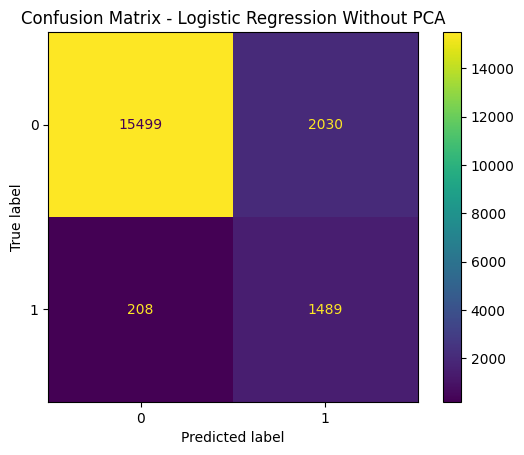

In [108]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_log_reg)

plt.title("Confusion Matrix - Logistic Regression Without PCA")
plt.show()

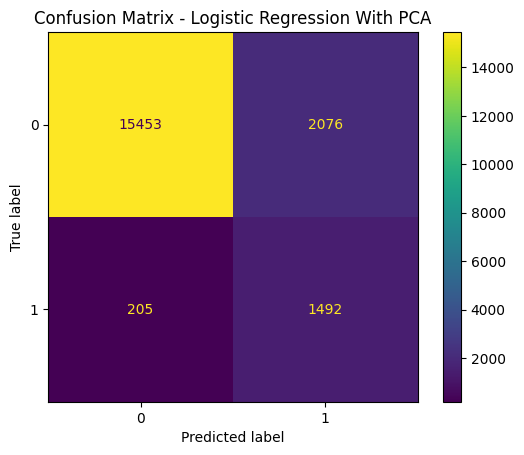

In [109]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_log_reg_pca)

plt.title("Confusion Matrix - Logistic Regression With PCA")
plt.show()

MLP

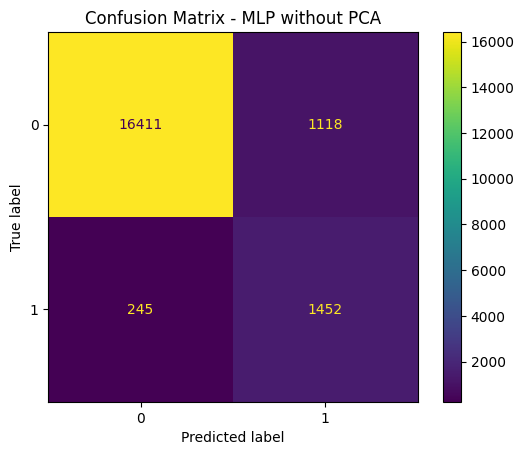

In [110]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_best_MLP)

plt.title("Confusion Matrix - MLP without PCA")
plt.show()

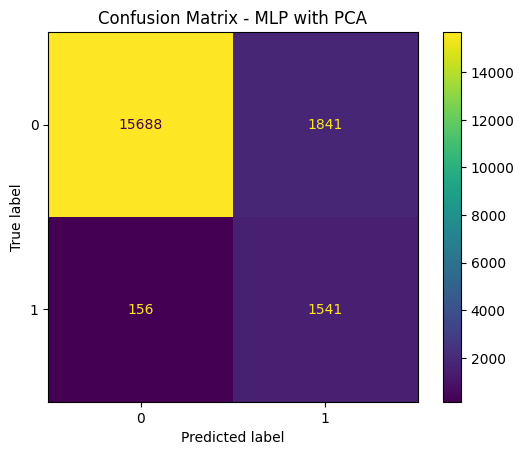

In [111]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_best_MLP_pca)

plt.title("Confusion Matrix - MLP with PCA")
plt.show()

**SVM**

**Linear SVM**

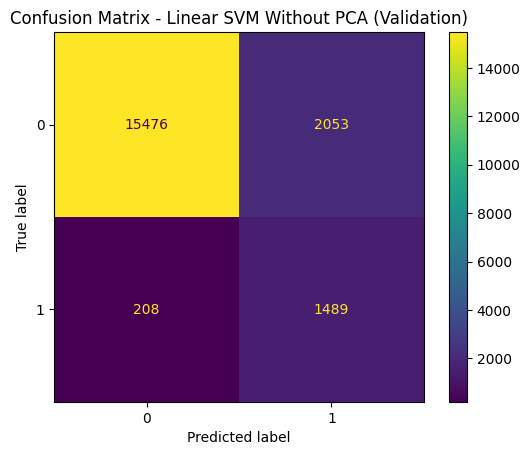

In [112]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_linear)

plt.title("Confusion Matrix - Linear SVM Without PCA (Validation)")
plt.show()

**RBF SVM**

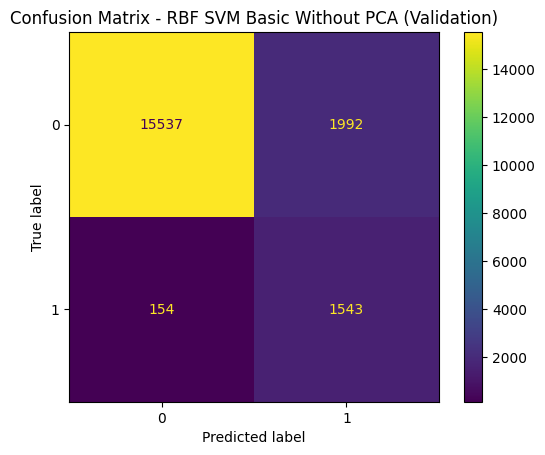

In [113]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_rbf_basic)

plt.title("Confusion Matrix - RBF SVM Basic Without PCA (Validation)")
plt.show()


**RBF SVM (Grid Search)**

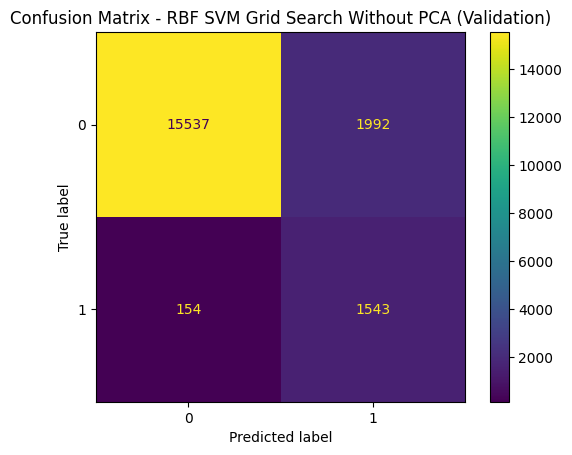

In [114]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_grid)

plt.title("Confusion Matrix - RBF SVM Grid Search Without PCA (Validation)")
plt.show()

**RBF SVM (PSO)**

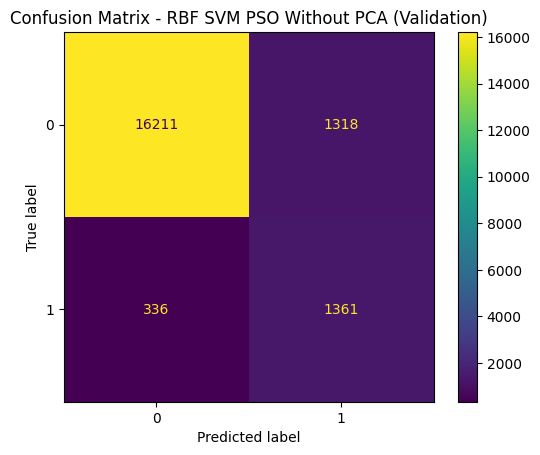

In [115]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_pso)

plt.title("Confusion Matrix - RBF SVM PSO Without PCA (Validation)")
plt.show()

**PCA Models**

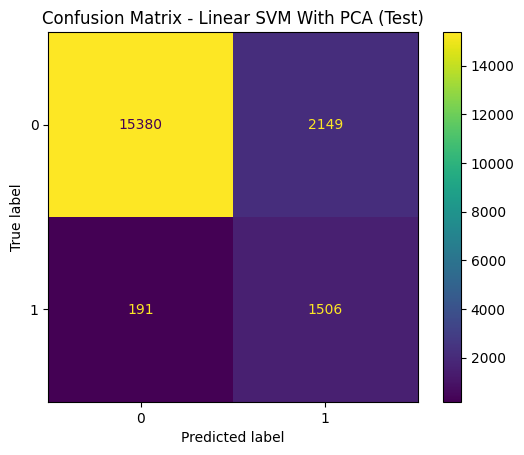

In [116]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_linear_pca)

plt.title("Confusion Matrix - Linear SVM With PCA (Test)")
plt.show()

**RBF SVM with PCA**

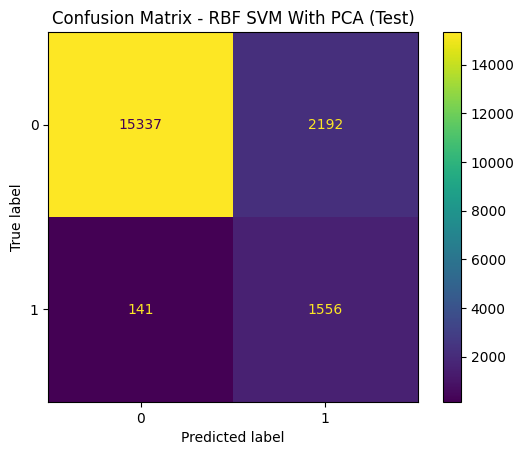

In [117]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_rbf_pca)

plt.title("Confusion Matrix - RBF SVM With PCA (Test)")
plt.show()

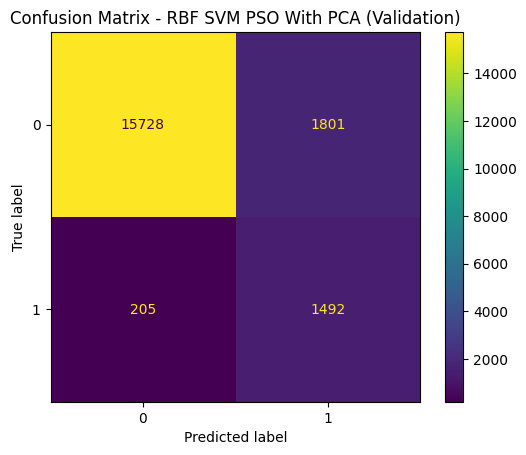

In [118]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_pso_pca)

plt.title("Confusion Matrix - RBF SVM PSO With PCA (Validation)")
plt.show()

Naive Bayes

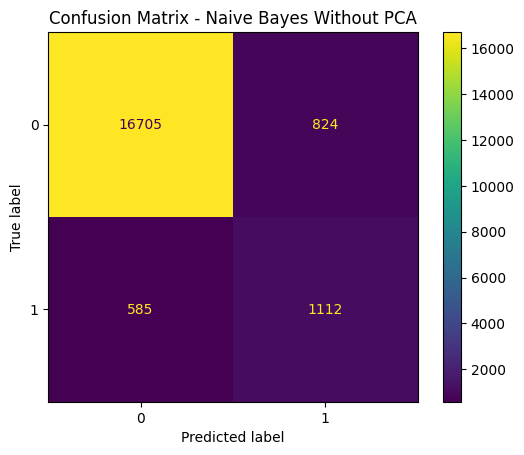

In [119]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_nb)
plt.title("Confusion Matrix - Naive Bayes Without PCA")
plt.show()

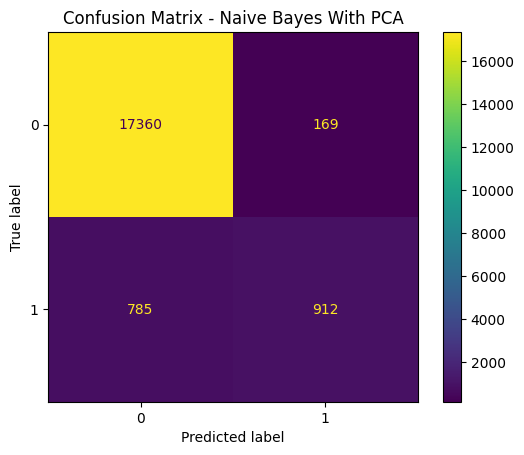

In [120]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_nb_pca)
plt.title("Confusion Matrix - Naive Bayes With PCA")
plt.show()

Random Forest

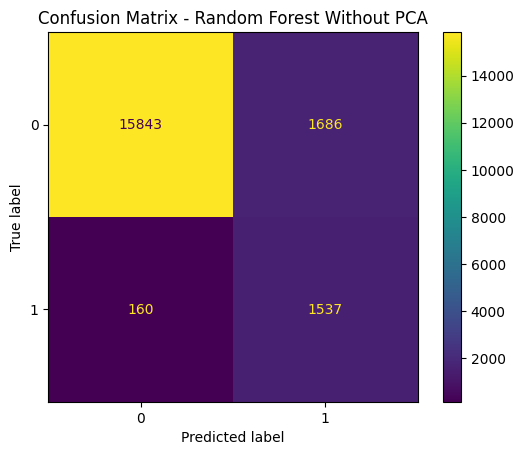

In [121]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_rf)

plt.title("Confusion Matrix - Random Forest Without PCA")
plt.show()

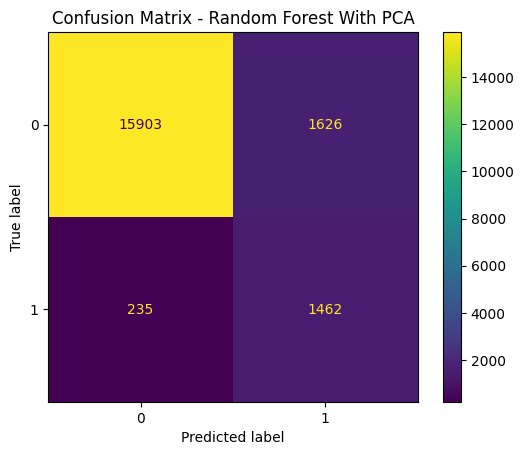

In [122]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_rf_pca)

plt.title("Confusion Matrix - Random Forest With PCA")
plt.show()

Gradient Boosting

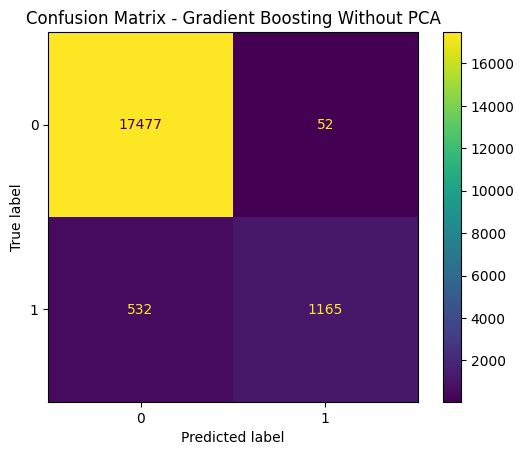

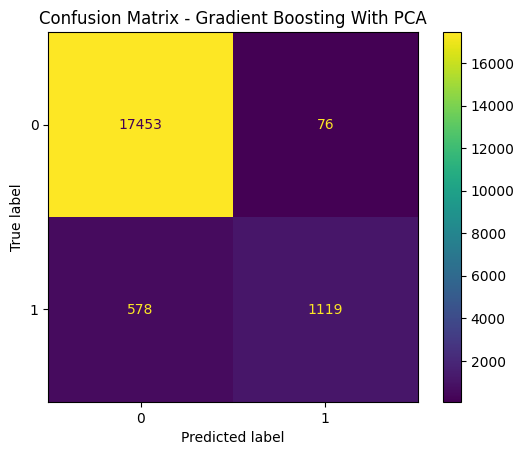

In [123]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_gb)

plt.title("Confusion Matrix - Gradient Boosting Without PCA")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_gb_pca)

plt.title("Confusion Matrix - Gradient Boosting With PCA")
plt.show()

AdaBoosting

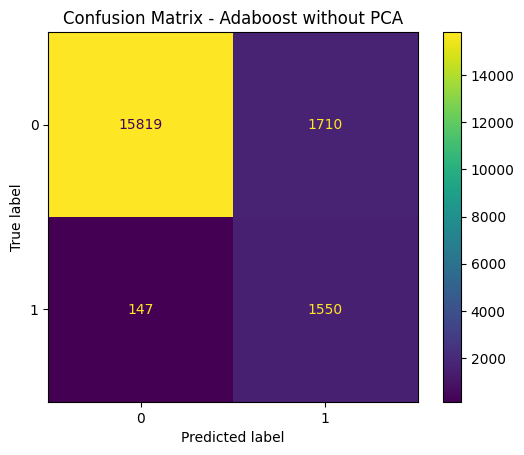

In [124]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_best_ada)

plt.title("Confusion Matrix - Adaboost without PCA")
plt.show()

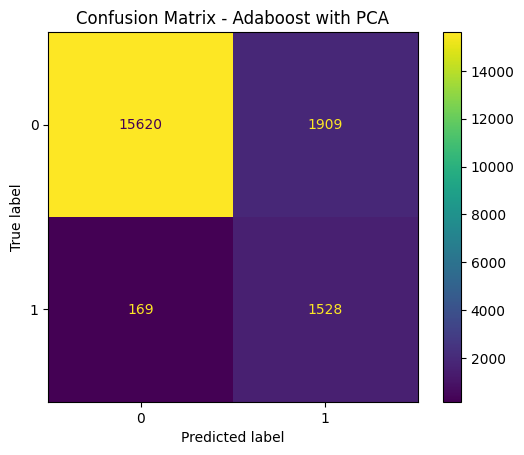

In [125]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_best_ada_pca)

plt.title("Confusion Matrix - Adaboost with PCA")
plt.show()

XGBoosting

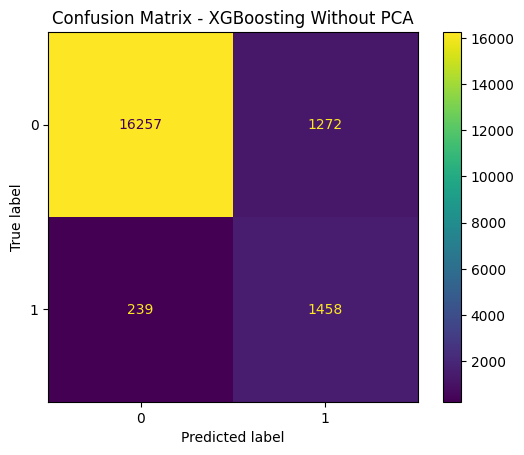

In [126]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_xgb)
plt.title("Confusion Matrix - XGBoosting Without PCA")
plt.show()

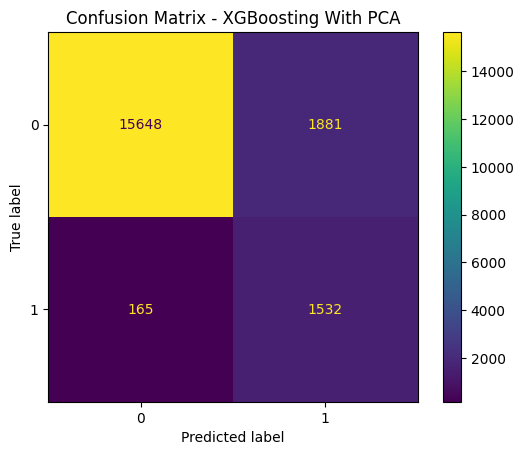

In [127]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_xgb_pca)
plt.title("Confusion Matrix - XGBoosting With PCA")
plt.show()

Accuracy Comparison Across all models

# **Learning curve and graphs**

Comparisons Graphs

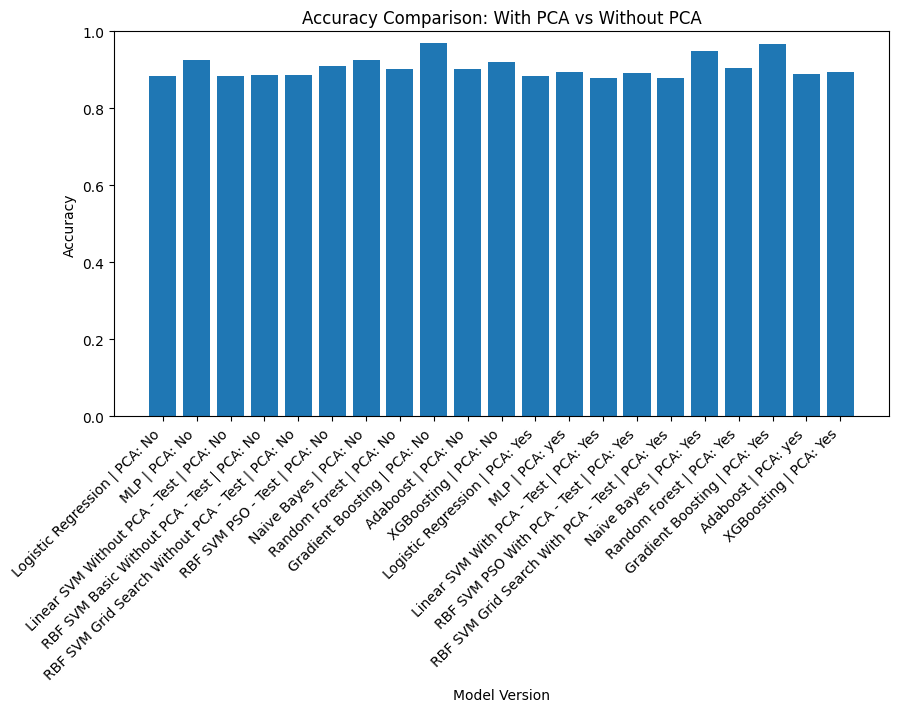

In [128]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Model Version"], results_df["Accuracy"])

plt.title("Accuracy Comparison: With PCA vs Without PCA")
plt.xlabel("Model Version")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

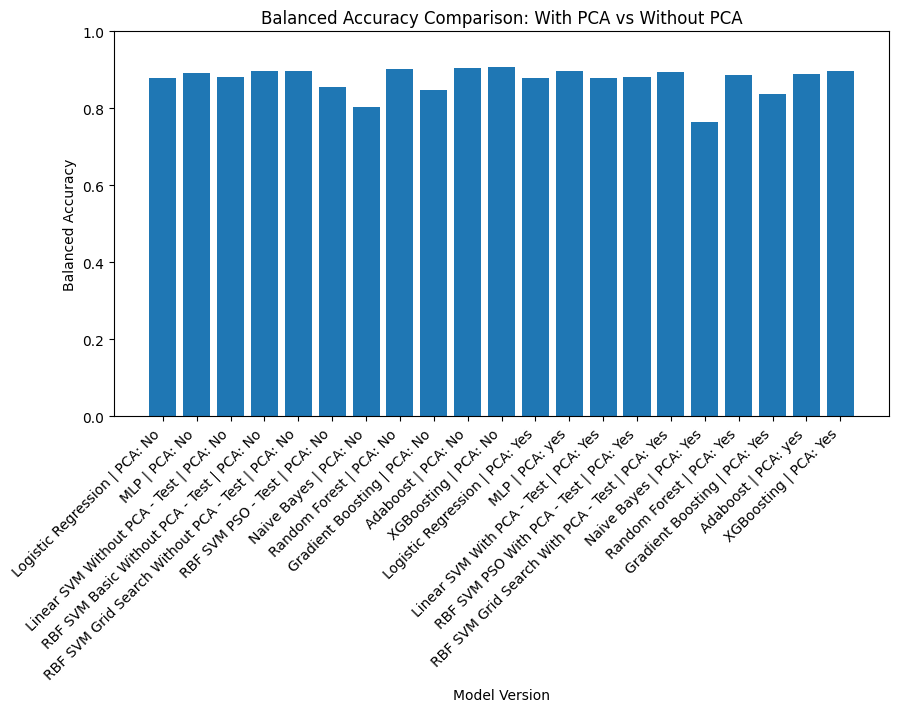

In [129]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Model Version"], results_df["Balanced Accuracy"])

plt.title("Balanced Accuracy Comparison: With PCA vs Without PCA")
plt.xlabel("Model Version")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

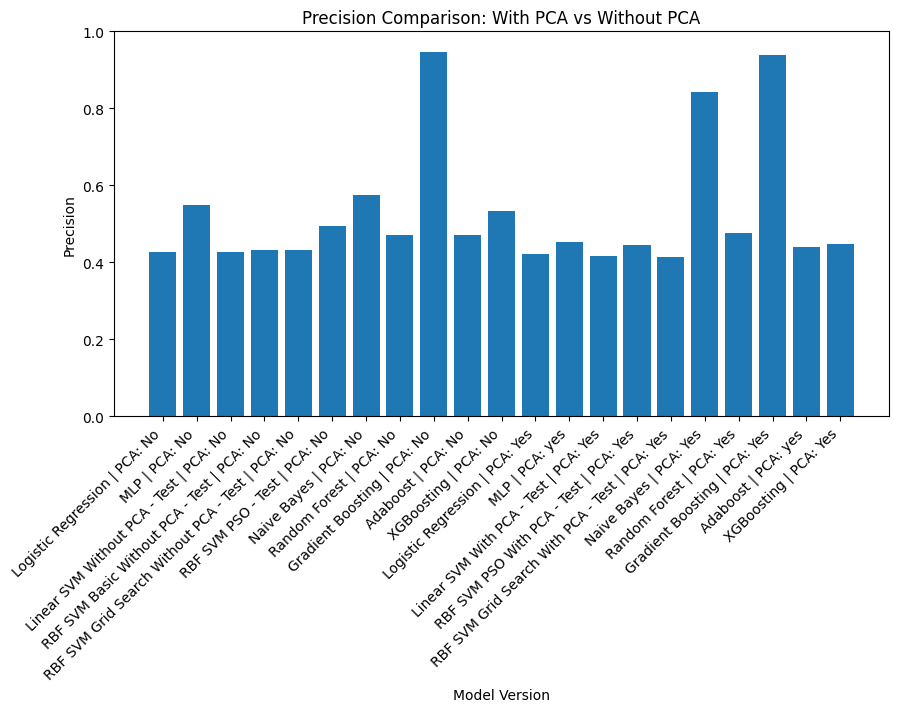

In [130]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Model Version"], results_df["Precision"])

plt.title("Precision Comparison: With PCA vs Without PCA")
plt.xlabel("Model Version")
plt.ylabel("Precision")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

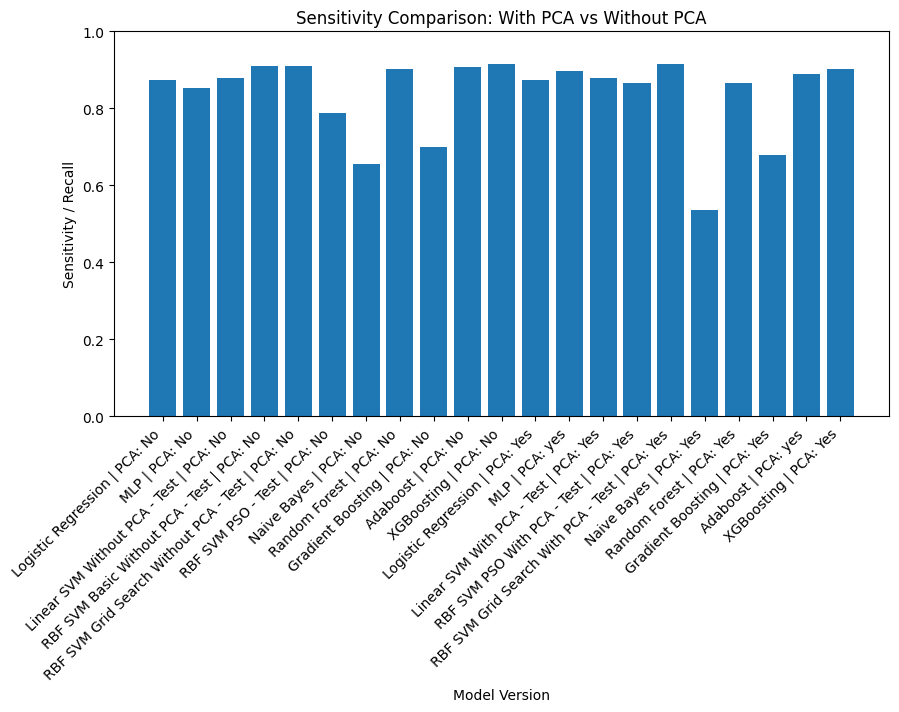

In [131]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Model Version"], results_df["Sensitivity"])

plt.title("Sensitivity Comparison: With PCA vs Without PCA")
plt.xlabel("Model Version")
plt.ylabel("Sensitivity / Recall")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

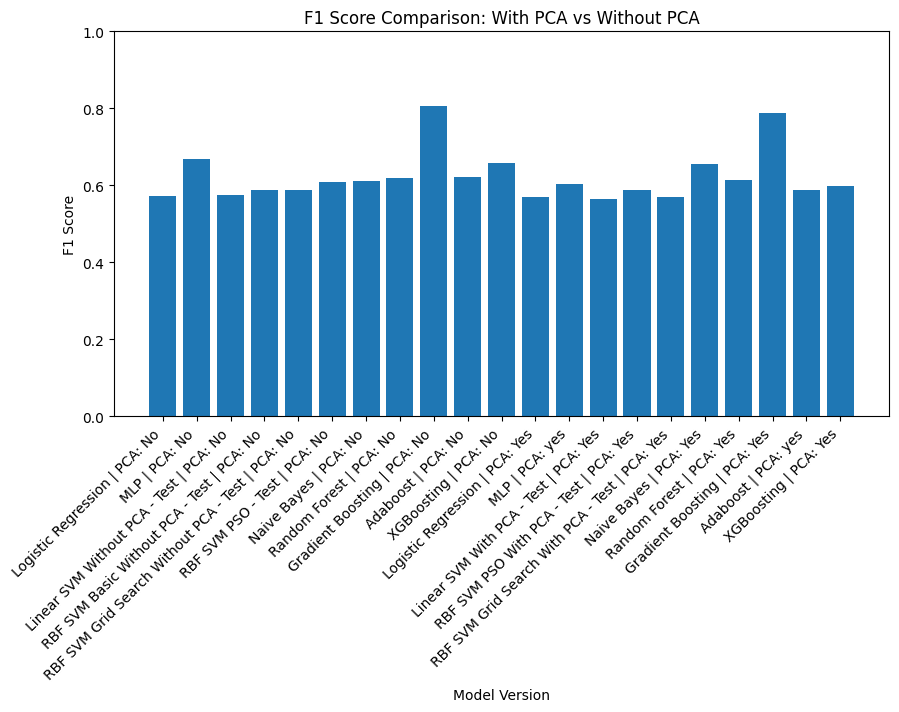

In [132]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Model Version"], results_df["F1 Score"])

plt.title("F1 Score Comparison: With PCA vs Without PCA")
plt.xlabel("Model Version")
plt.ylabel("F1 Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

Learning curves

In [133]:
def plot_learning_curve(model, model_name, X_train_data, y_train_data, X_val_data, y_val_data):
    train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0]

    train_acc_scores = []
    val_acc_scores = []

    train_f1_scores = []
    val_f1_scores = []

    for size in train_sizes:
        sample_size = int(len(X_train_data) * size)

        X_subset = X_train_data[:sample_size]
        y_subset = y_train_data.iloc[:sample_size]

        model_copy = clone(model)
        model_copy.fit(X_subset, y_subset)

        y_train_pred = model_copy.predict(X_subset)
        y_val_pred = model_copy.predict(X_val_data)

        train_acc_scores.append(balanced_accuracy_score(y_subset, y_train_pred))
        val_acc_scores.append(balanced_accuracy_score(y_val_data, y_val_pred))

        train_f1_scores.append(f1_score(y_subset, y_train_pred, zero_division=0))
        val_f1_scores.append(f1_score(y_val_data, y_val_pred, zero_division=0))

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_acc_scores, marker="o", label="Training Accuracy")
    plt.plot(train_sizes, val_acc_scores, marker="o", label="Validation Accuracy")
    plt.title(f"Learning Curve - Accuracy: {model_name}")
    plt.xlabel("Training Data Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_f1_scores, marker="o", label="Training F1 Score")
    plt.plot(train_sizes, val_f1_scores, marker="o", label="Validation F1 Score")
    plt.title(f"Learning Curve - F1 Score: {model_name}")
    plt.xlabel("Training Data Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()

In [134]:
def plot_learning_curve_for_mlp(model, model_name, X_train_data, y_train_data, X_val_data, y_val_data):
    train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0]

    train_acc_scores = []
    val_acc_scores = []

    train_f1_scores = []
    val_f1_scores = []


    for size in train_sizes:
        sample_size = int(len(X_train_data) * size)

        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_train[:sample_size]
        )
        X_subset = X_train_data[:sample_size]
        y_subset = y_train_data.iloc[:sample_size]

        model_copy = clone(model)
        model_copy.fit(X_subset, y_subset,sample_weight=sample_weights)

        y_train_pred = model_copy.predict(X_subset)
        y_val_pred = model_copy.predict(X_val_data)

        train_acc_scores.append(balanced_accuracy_score(y_subset, y_train_pred))
        val_acc_scores.append(balanced_accuracy_score(y_val_data, y_val_pred))

        train_f1_scores.append(f1_score(y_subset, y_train_pred, zero_division=0))
        val_f1_scores.append(f1_score(y_val_data, y_val_pred, zero_division=0))

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_acc_scores, marker="o", label="Training Accuracy")
    plt.plot(train_sizes, val_acc_scores, marker="o", label="Validation Accuracy")
    plt.title(f"Learning Curve - Accuracy: {model_name}")
    plt.xlabel("Training Data Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_f1_scores, marker="o", label="Training F1 Score")
    plt.plot(train_sizes, val_f1_scores, marker="o", label="Validation F1 Score")
    plt.title(f"Learning Curve - F1 Score: {model_name}")
    plt.xlabel("Training Data Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()

Logistic graphs

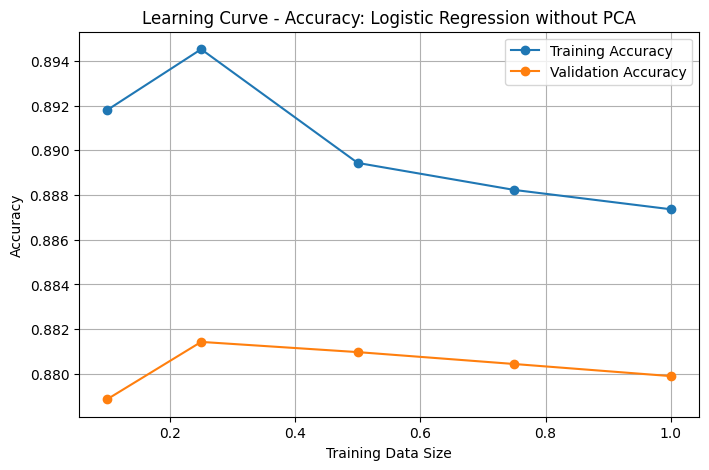

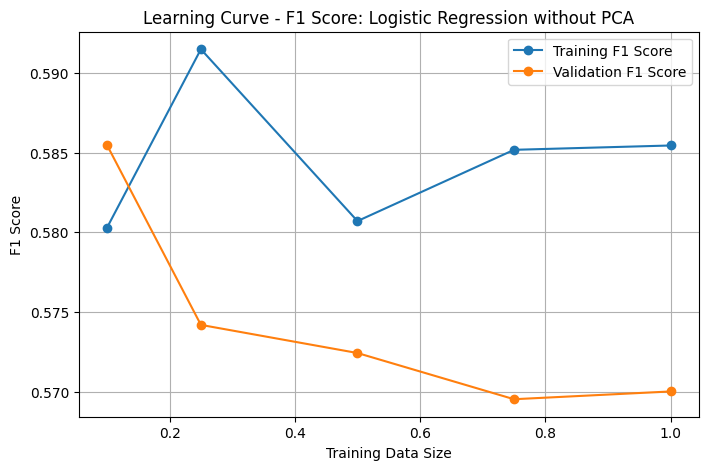

In [135]:
log_reg_lc = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

plot_learning_curve(
    model=log_reg_lc,
    model_name="Logistic Regression without PCA",
    X_train_data=X_train_processed,
    y_train_data=y_train,
    X_val_data=X_val_processed,
    y_val_data=y_val
)

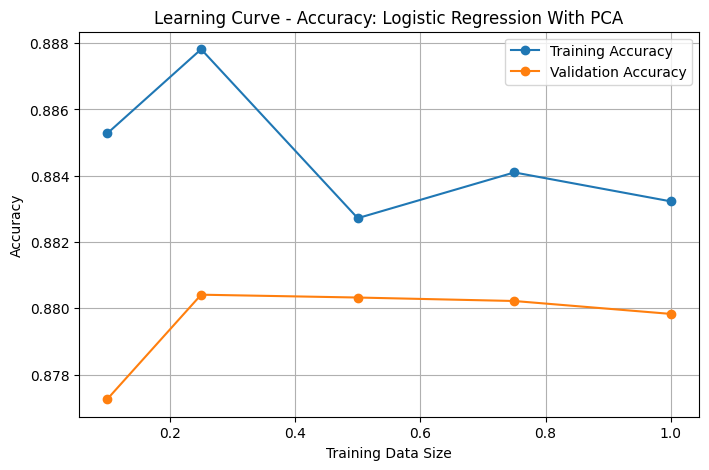

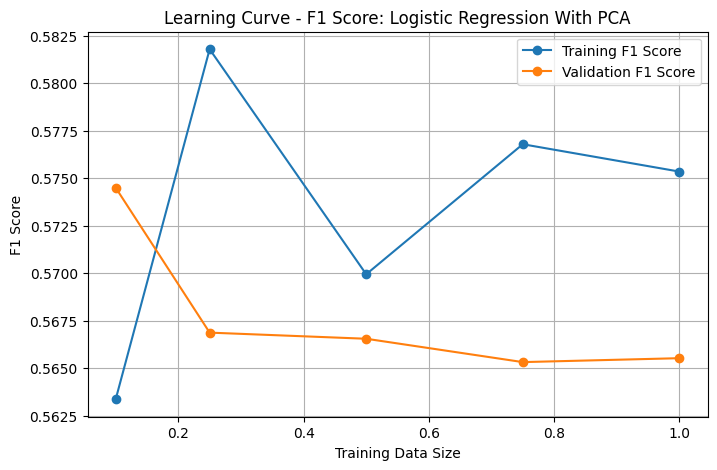

In [136]:
log_reg_pca_lc = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

plot_learning_curve(
    model=log_reg_pca_lc,
    model_name="Logistic Regression With PCA",
    X_train_data=X_train_pca,
    y_train_data=y_train,
    X_val_data=X_val_pca,
    y_val_data=y_val
)

MLP Grpahs

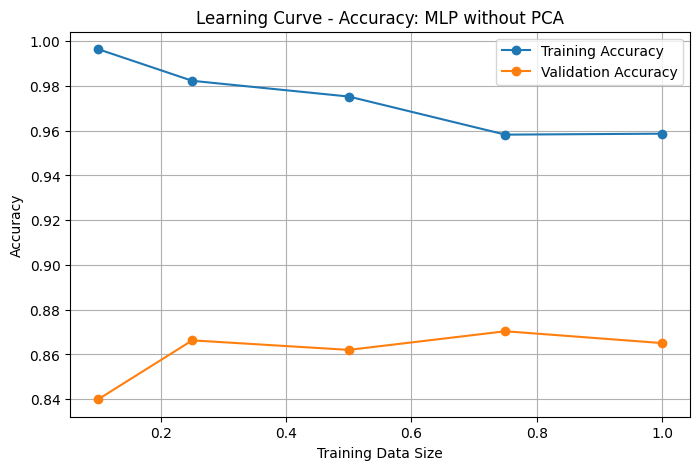

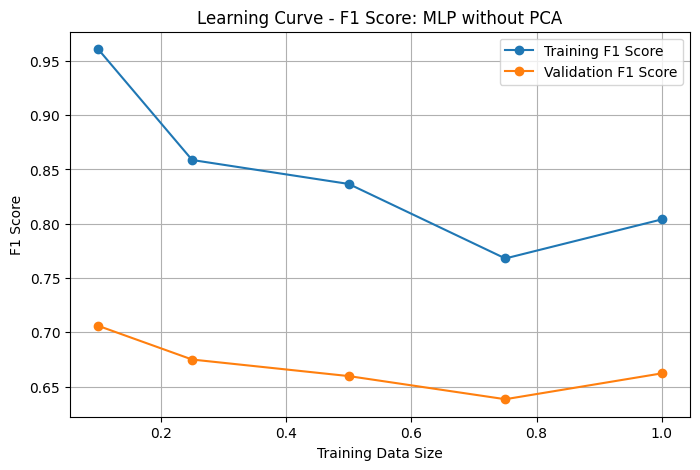

In [137]:
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
plot_learning_curve_for_mlp(
    model=mlp,
    model_name="MLP without PCA",
    X_train_data=X_train_processed,
    y_train_data=y_train,
    X_val_data=X_val_processed,
    y_val_data=y_val
)

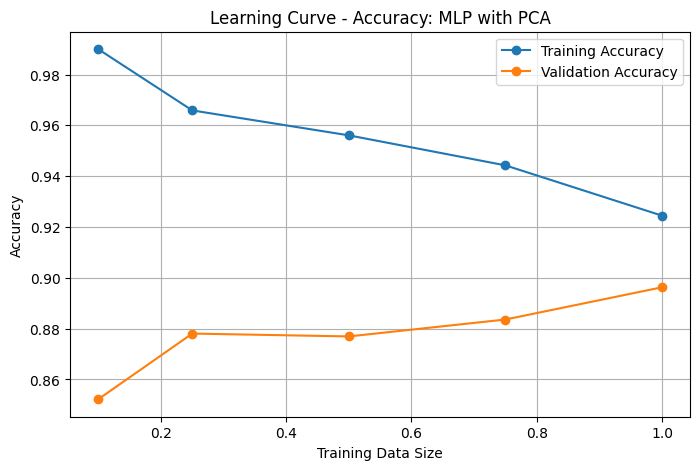

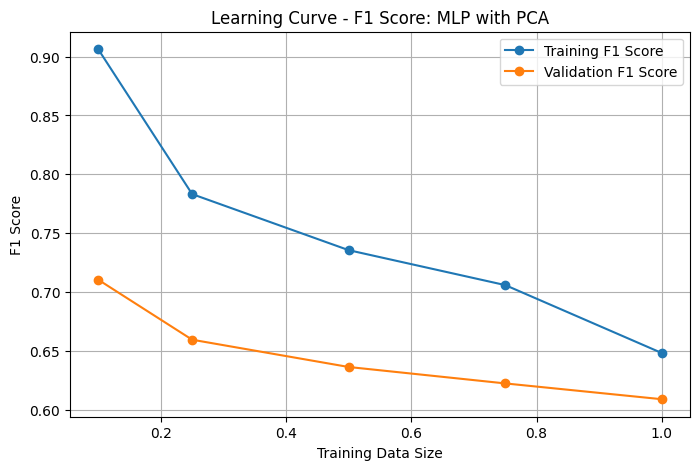

In [138]:

plot_learning_curve_for_mlp(
    model=mlp,
    model_name="MLP with PCA",
    X_train_data=X_train_pca,
    y_train_data=y_train,
    X_val_data=X_val_pca,
    y_val_data=y_val
)

SVM Graphs

**Linear SVM**

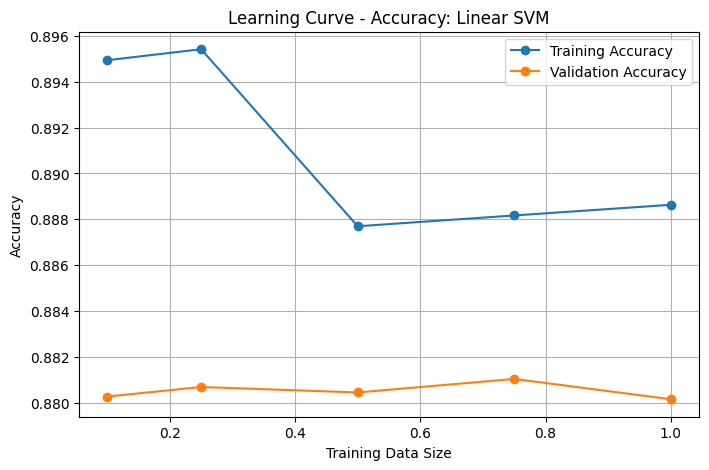

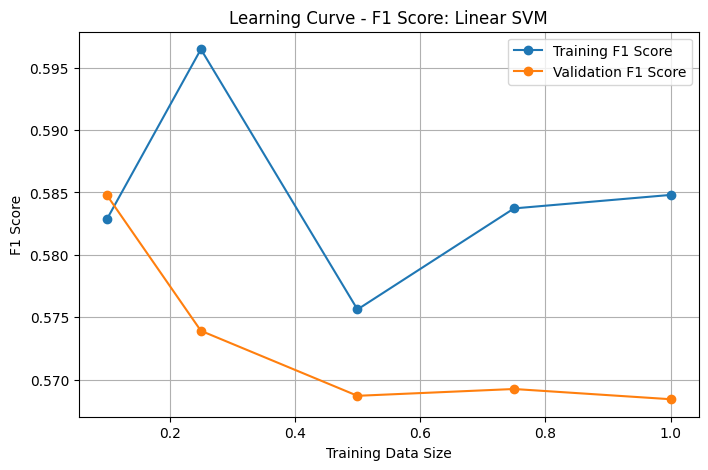

In [139]:

plot_learning_curve(
    linear_svm,
    "Linear SVM",
    X_train_processed,
    y_train,
    X_val_processed,
    y_val
)


**RBF SVM (Grid Search best)**

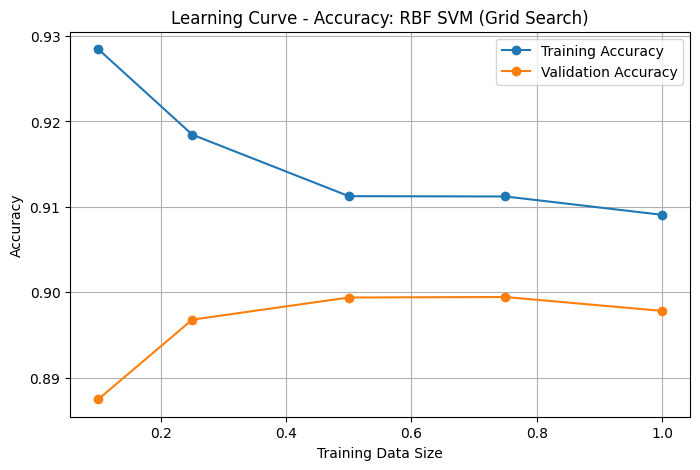

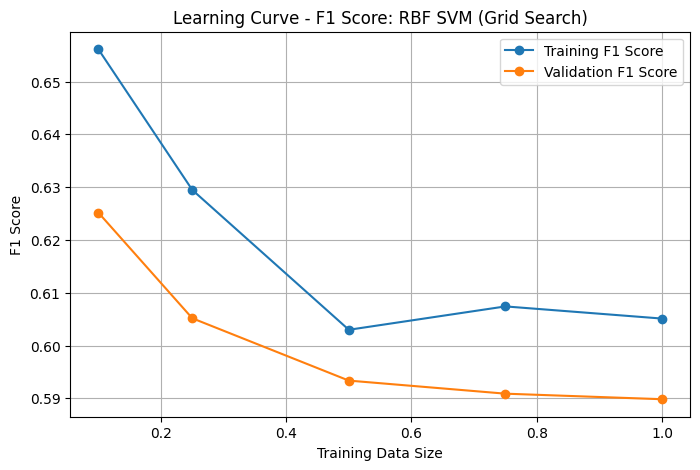

In [140]:
plot_learning_curve(
    rbf_svm_grid,
    "RBF SVM (Grid Search)",
    X_train_processed,
    y_train,
    X_val_processed,
    y_val
)

**PSO Model**

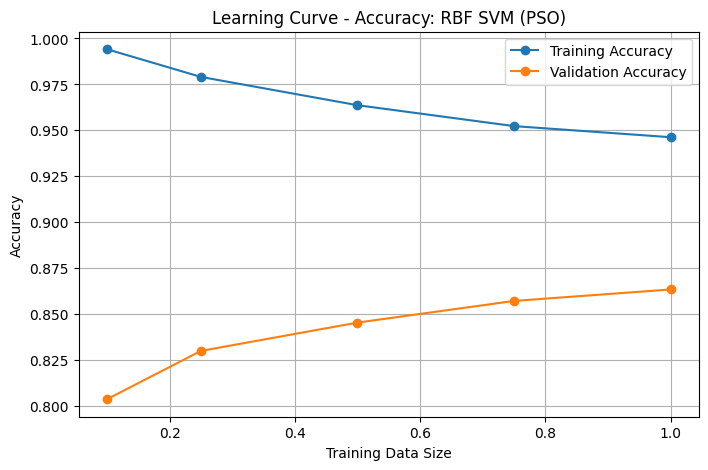

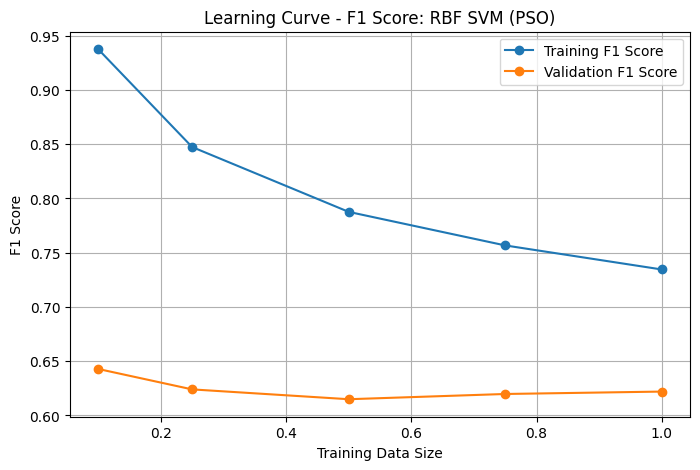

In [141]:

plot_learning_curve(
    svm_pso_final,
    "RBF SVM (PSO)",
    X_train_processed,
    y_train,
    X_val_processed,
    y_val
)


**PCA version**

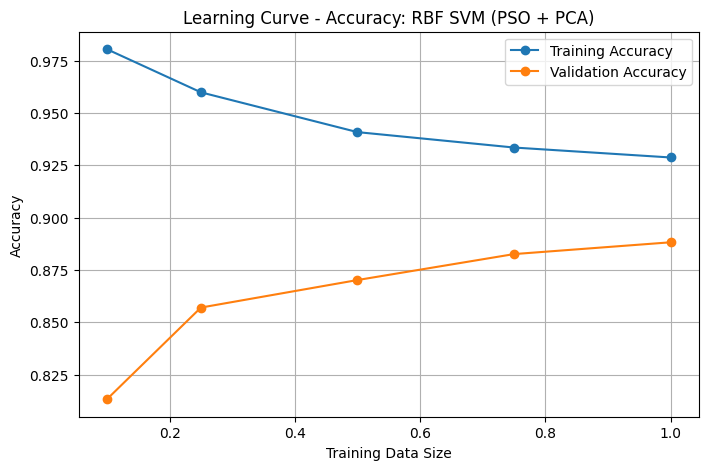

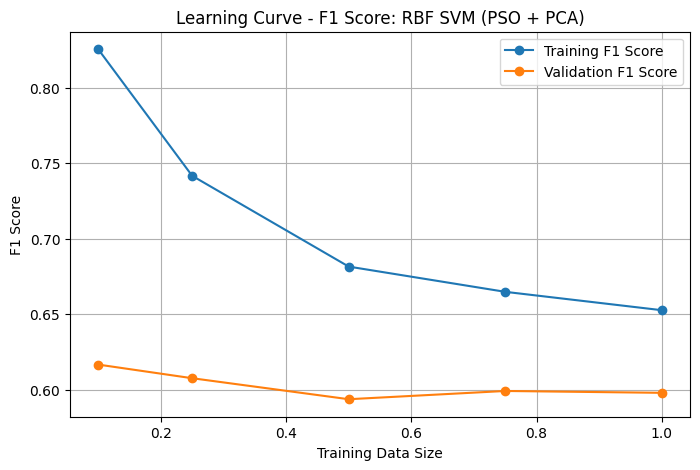

In [142]:
plot_learning_curve(
    svm_pso_pca_final,
    "RBF SVM (PSO + PCA)",
    X_train_pca,
    y_train,
    X_val_pca,
    y_val
)

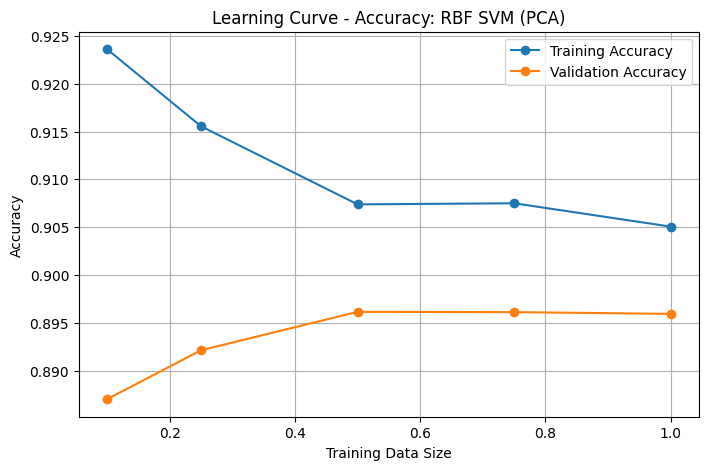

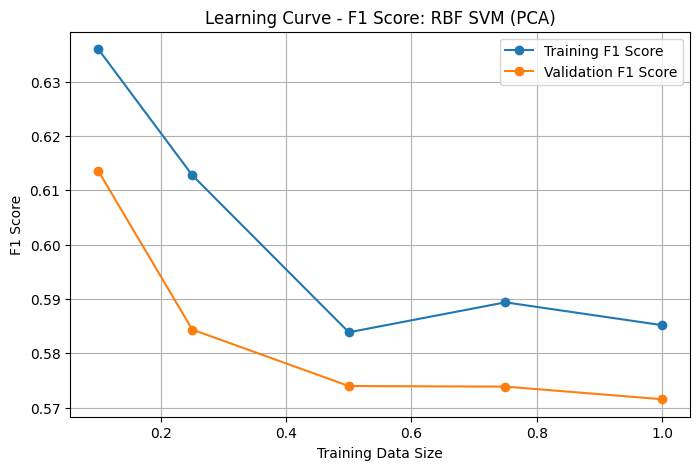

In [143]:
plot_learning_curve(
    rbf_svm_pca,
    "RBF SVM (PCA)",
    X_train_pca,
    y_train,
    X_val_pca,
    y_val
)

Naive Bayes Graphs

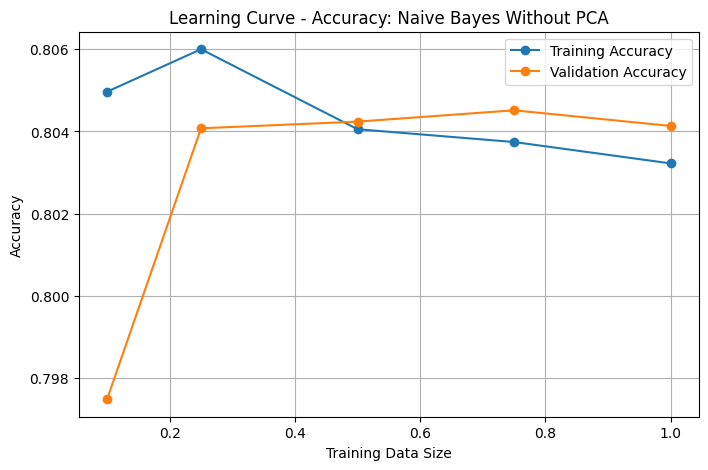

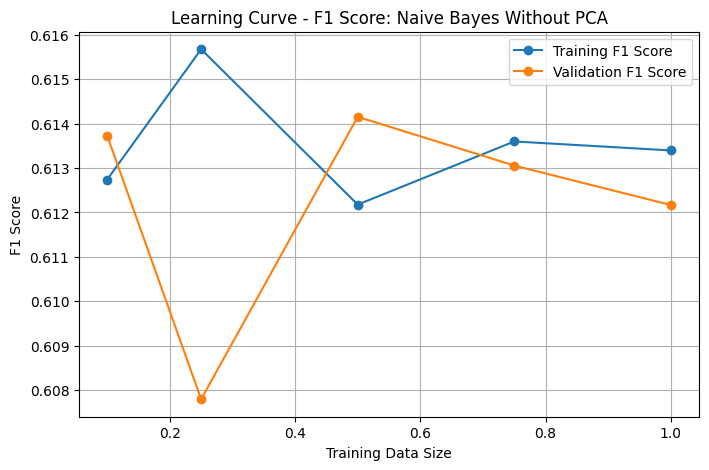

In [144]:
plot_learning_curve(
    model=GaussianNB(var_smoothing=best_vs_no_pca),
    model_name="Naive Bayes Without PCA",
    X_train_data=X_train_processed,
    y_train_data=y_train,
    X_val_data=X_val_processed,
    y_val_data=y_val
)

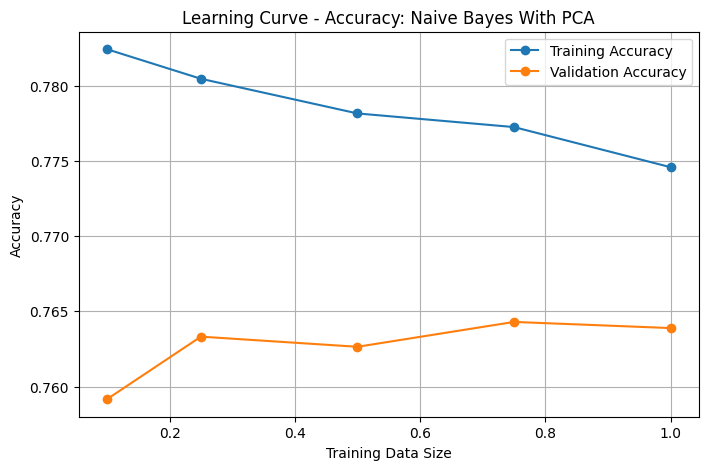

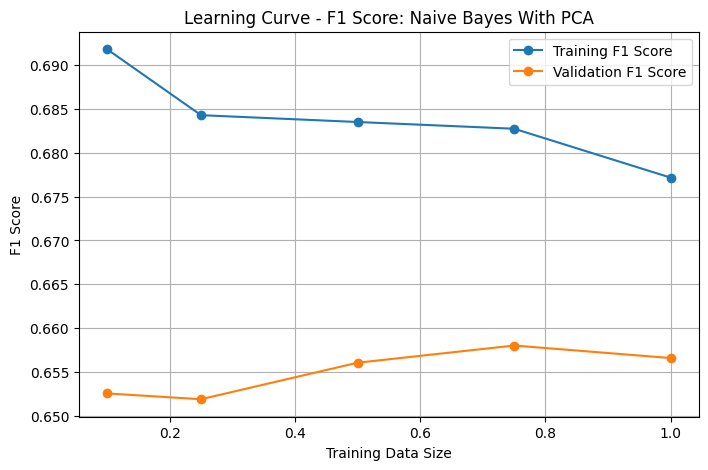

In [145]:
plot_learning_curve(
    model=GaussianNB(var_smoothing=best_vs_pca),
    model_name="Naive Bayes With PCA",
    X_train_data=X_train_pca,
    y_train_data=y_train,
    X_val_data=X_val_pca,
    y_val_data=y_val
)

Random forest graphs

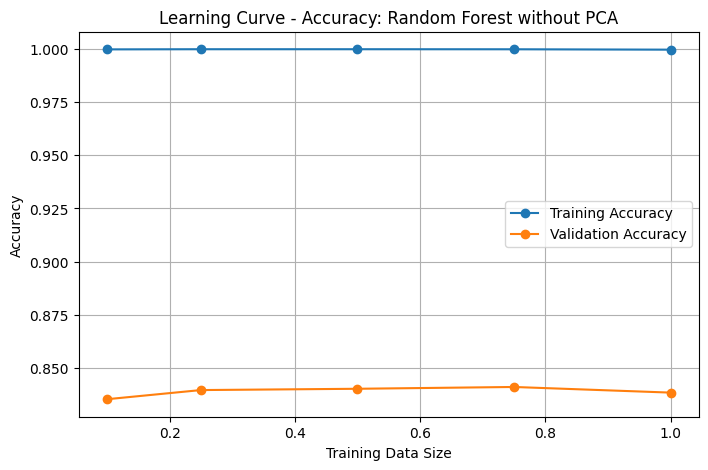

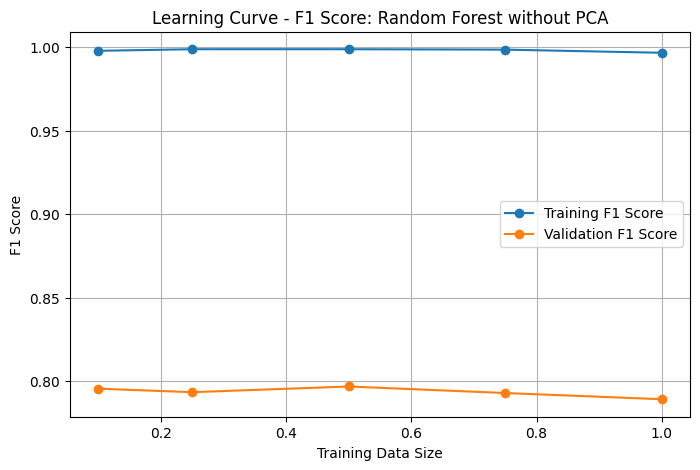

In [146]:
rf_lc = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

plot_learning_curve(
    model=rf_lc,
    model_name="Random Forest without PCA",
    X_train_data=X_train_processed,
    y_train_data=y_train,
    X_val_data=X_val_processed,
    y_val_data=y_val
)

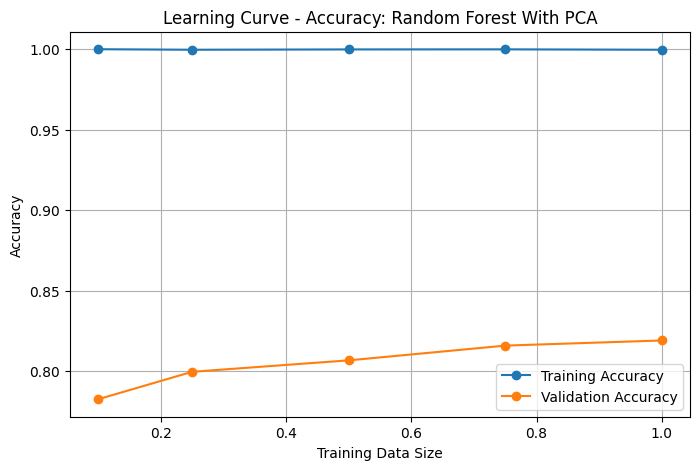

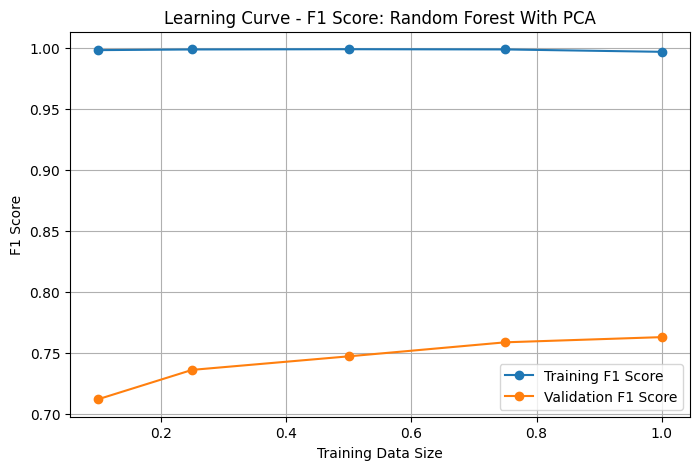

In [147]:
rf_pca_lc = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

plot_learning_curve(
    model=rf_pca_lc,
    model_name="Random Forest With PCA",
    X_train_data=X_train_pca,
    y_train_data=y_train,
    X_val_data=X_val_pca,
    y_val_data=y_val
)

Gradient Boosting Graphs

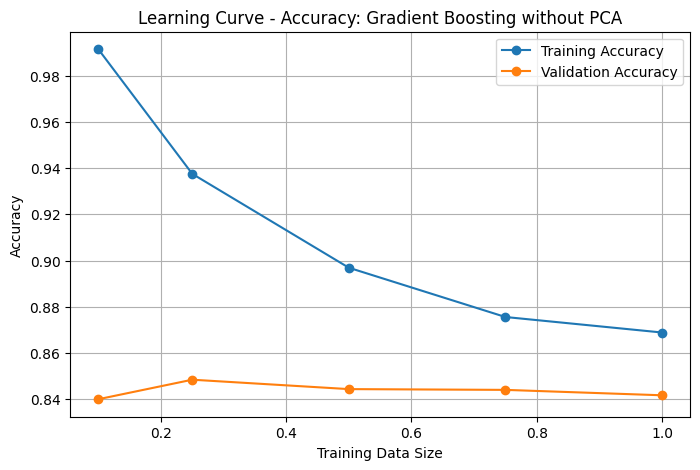

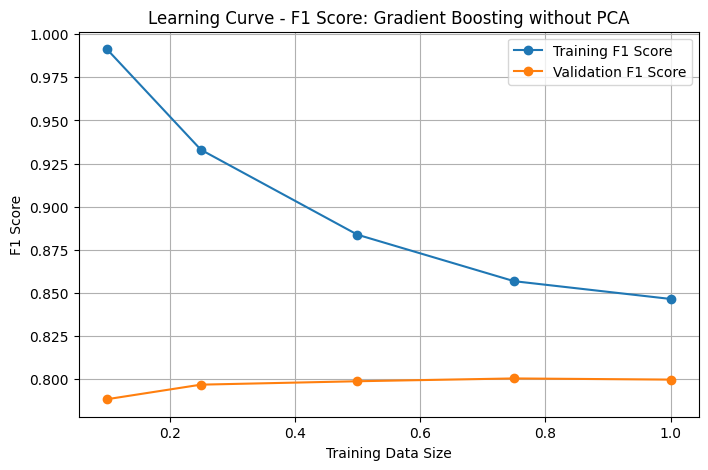

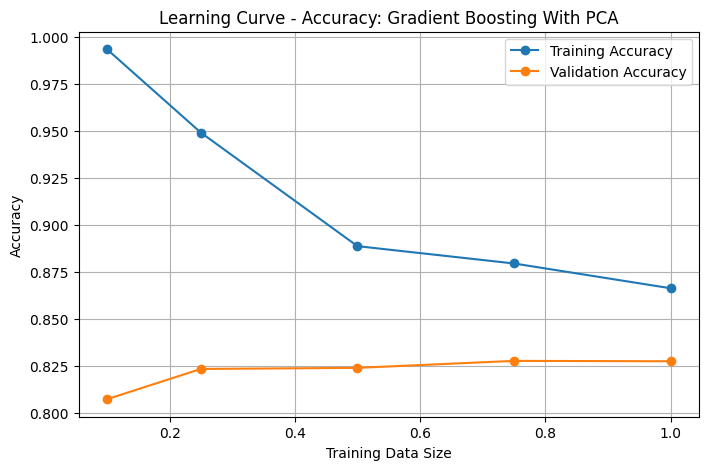

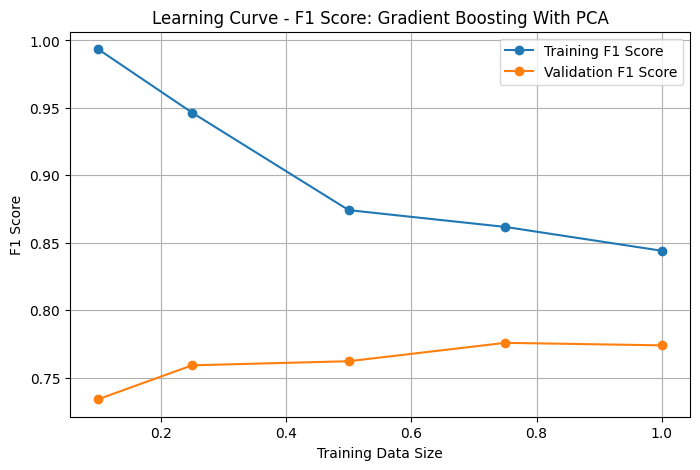

In [148]:
plot_learning_curve(
    model=best_gb,
    model_name="Gradient Boosting without PCA",
    X_train_data=X_train_processed,
    y_train_data=y_train,
    X_val_data=X_val_processed,
    y_val_data=y_val
)



plot_learning_curve(
    model=best_gb_pca,
    model_name="Gradient Boosting With PCA",
    X_train_data=X_train_pca,
    y_train_data=y_train,
    X_val_data=X_val_pca,
    y_val_data=y_val
)

Adaboosting graphs

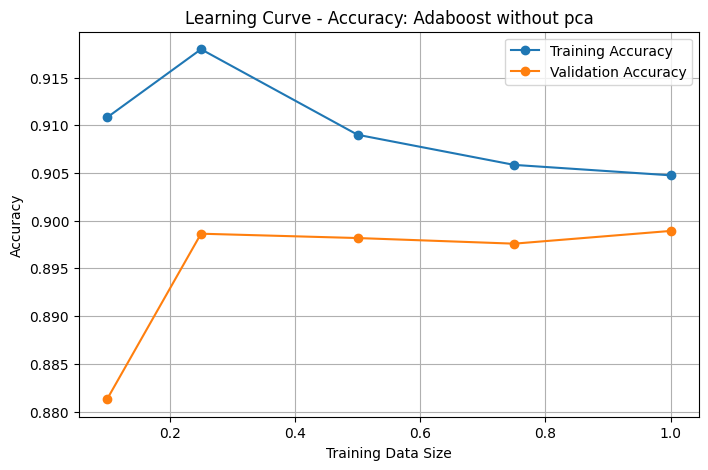

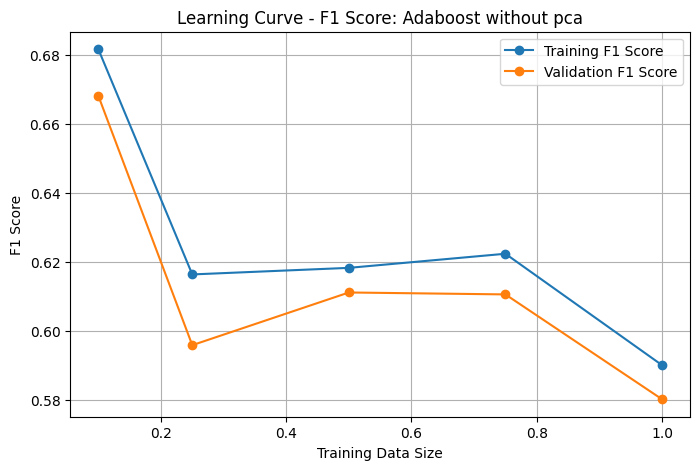

In [149]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

plot_learning_curve_for_mlp(
    model=adaboost_model,
    model_name='Adaboost without pca',
    X_train_data=X_train_processed,
    y_train_data=y_train,
    X_val_data=X_val_processed,
    y_val_data=y_val
)

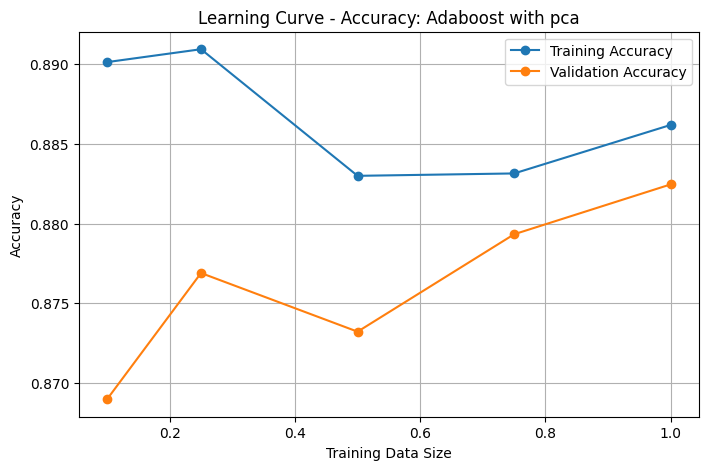

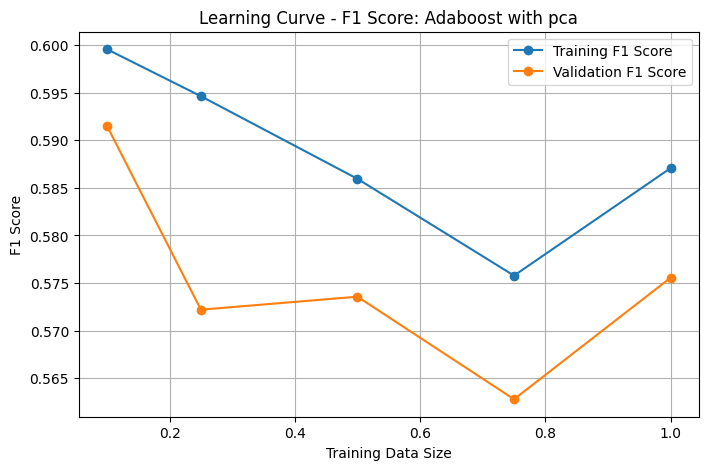

In [150]:
plot_learning_curve_for_mlp(
    model=adaboost_model,
    model_name='Adaboost with pca',
    X_train_data=X_train_pca,
    y_train_data=y_train,
    X_val_data=X_val_pca,
    y_val_data=y_val
)

XGBoosting Graphs

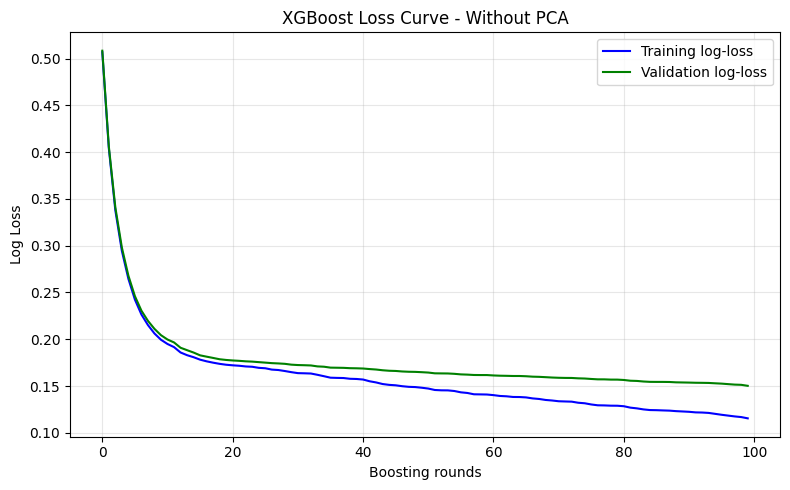

In [151]:
results_xgb = xgb_no_pca.evals_result()
keys = list(results_xgb.keys())
epochs = len(results_xgb[keys[0]]['logloss'])

plt.figure(figsize=(8, 5))
plt.plot(range(epochs), results_xgb[keys[0]]['logloss'],
         color='blue', label='Training log-loss')
plt.plot(range(epochs), results_xgb[keys[1]]['logloss'],
         color='green', label='Validation log-loss')
plt.title('XGBoost Loss Curve - Without PCA')
plt.xlabel('Boosting rounds')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:13:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder", "xgb_model" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:13:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder", "xgb_model" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:13:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder", "xgb_model" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\nourw\OneDrive\Desktop\Pr

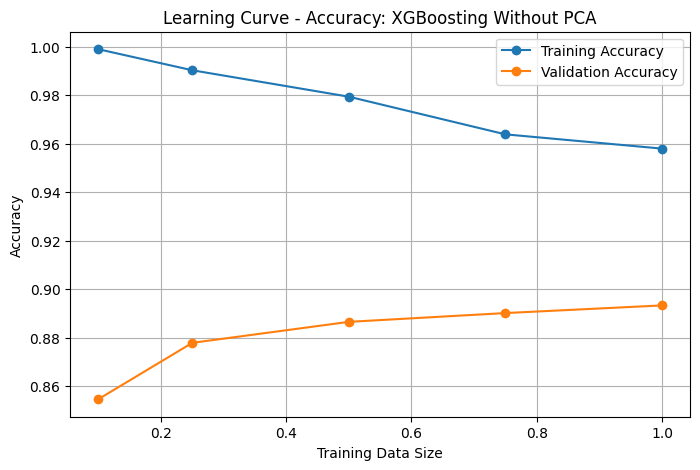

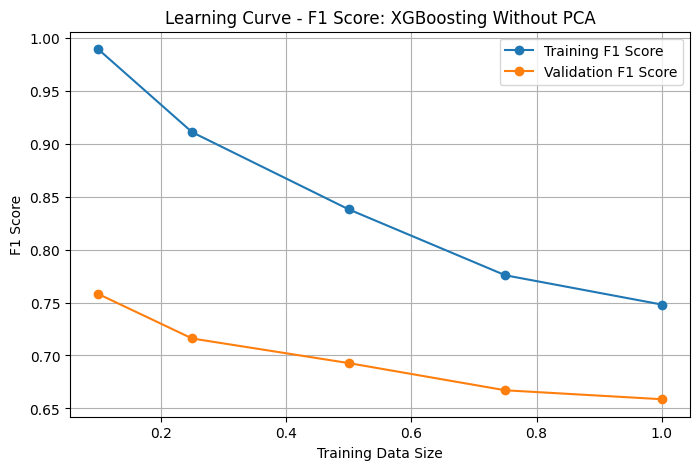

In [152]:
plot_learning_curve(
    model=XGBClassifier(xgb_model = best_xgb_no_pca, scale_pos_weight=scale_weight,
                        eval_metric='logloss', random_state=42, use_label_encoder=False),
    model_name="XGBoosting Without PCA",
    X_train_data=X_train_processed,
    y_train_data=y_train,
    X_val_data=X_val_processed,
    y_val_data=y_val
)

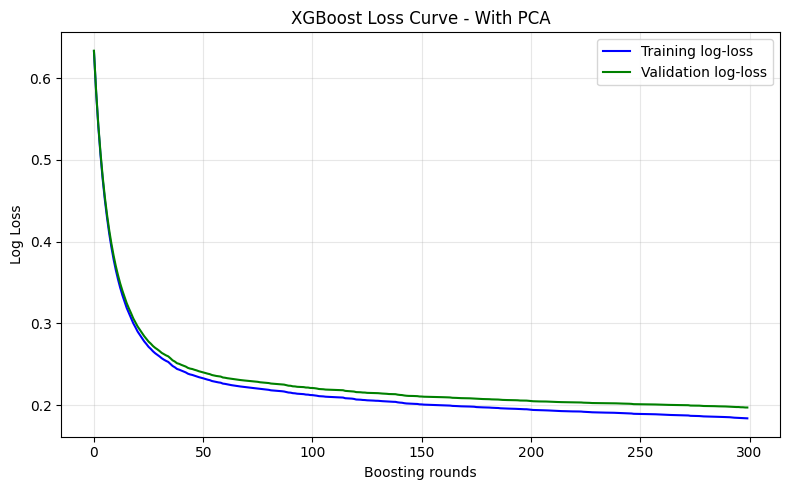

In [153]:
results_xgb_pca = xgb_with_pca.evals_result()
keys_pca = list(results_xgb_pca.keys())
epochs_pca = len(results_xgb_pca[keys_pca[0]]['logloss'])

plt.figure(figsize=(8, 5))
plt.plot(range(epochs_pca), results_xgb_pca[keys_pca[0]]['logloss'],
         color='blue', label='Training log-loss')
plt.plot(range(epochs_pca), results_xgb_pca[keys_pca[1]]['logloss'],
         color='green', label='Validation log-loss')
plt.title('XGBoost Loss Curve - With PCA')
plt.xlabel('Boosting rounds')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:13:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:13:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:13:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\nourw\OneDrive\Desktop\Projects\Year 3\Machine Learning\Task2\.v

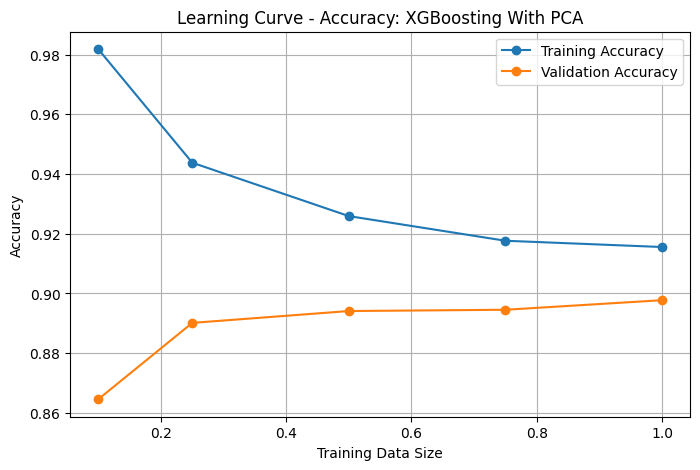

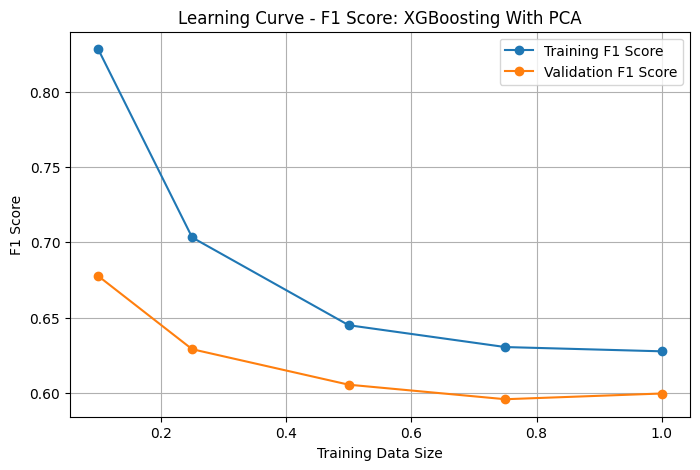

In [154]:
plot_learning_curve(
    model=XGBClassifier(**best_xgb_pca, scale_pos_weight=scale_weight,
                        eval_metric='logloss', random_state=42, use_label_encoder=False),
    model_name="XGBoosting With PCA",
    X_train_data=X_train_pca,
    y_train_data=y_train,
    X_val_data=X_val_pca,
    y_val_data=y_val
)

# **Final test evaluation**

In [155]:
# Choose the metric used to select the best model
# Recommended for imbalanced data: "F1 Score"
# If your instructor insists on accuracy, change it to "Accuracy"

selection_metric = "Balanced Accuracy"

best_row = results_df.sort_values(by=selection_metric, ascending=False).iloc[0]

best_model_name = best_row["Model"]
best_pca_status = best_row["PCA"]

print("Best model selected from validation results:")
print("Model:", best_model_name)
print("PCA:", best_pca_status)
print(f"Best validation {selection_metric}:", best_row[selection_metric])

Best model selected from validation results:
Model: XGBoosting
PCA: No
Best validation Balanced Accuracy: 0.908507585379242


In [156]:
model_registry = {
    ("Logistic Regression", "No") : best_log_reg,
    ("Logistic Regression", "Yes"): best_log_reg_pca,

    ("MLP", "No")                 : best_MLP_estmator_noPCA,
    ("MLP", "Yes")                : best_MLP_estmator_withPCA,

    ("Linear SVM", "No") : linear_svm,
    ("Linear SVM", "Yes"): linear_svm_pca,
    ("RBF SVM", "No") : rbf_svm_basic,
    ("RBF SVM", "Yes"): rbf_svm_pca,
    ("PSO", "No") : svm_pso_final,
    ("PSO", "Yes"): svm_pso_pca_final,

    ("Naive Bayes", "No")         : nb_no_pca,
    ("Naive Bayes", "Yes")        : nb_with_pca,

    ("Random Forest", "No")       : best_rf,
    ("Random Forest", "Yes")      : best_rf_pca,

    ("Gradient Boosting", "No")   : best_gb,
    ("Gradient Boosting", "Yes")  : best_gb_pca,

    ("Adaboosting", "No")         : best_ada_estmator_noPCA,
    ("Adaboosting", "Yes")        : best_ada_estmator_withPCA,

    ("XGBoosting", "No")          : xgb_no_pca,
    ("XGBoosting", "Yes")         : xgb_with_pca,



}

best_model = model_registry[(best_model_name, best_pca_status)]
print(best_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)


In [157]:
if best_pca_status == "Yes":
    X_test_final = X_test_pca
else:
    X_test_final = X_test_processed

In [158]:
y_test_pred_final = best_model.predict(X_test_final)

In [159]:
final_result = evaluate_model(
    model_name=best_model_name,
    pca_status=best_pca_status,
    y_true=y_test,
    y_pred=y_test_pred_final,
    print_report=True
)

========== XGBoosting | PCA: No ==========
Accuracy: 0.9200
Balanced Accuracy: 0.8957
Precision: 0.5284
Sensitivity / Recall: 0.8662
F1 Score: 0.6564

Confusion Matrix:
[[16219  1311]
 [  227  1469]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.95     17530
           1       0.53      0.87      0.66      1696

    accuracy                           0.92     19226
   macro avg       0.76      0.90      0.81     19226
weighted avg       0.95      0.92      0.93     19226



In [160]:
final_results_df = pd.DataFrame([final_result])

final_results_df["Selected By"] = selection_metric
final_results_df["Validation Selection Score"] = best_row[selection_metric]

final_results_df

,Model,PCA,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Sensitivity,F1 Score,Selected By,Validation Selection Score
0,XGBoosting,No,16219,1311,227,1469,0.920004,0.895685,0.528417,0.866156,0.65639,Balanced Accuracy,0.908508
